# Pipeline de PLN: Análise de Satisfação no E-Commerce Brasileiro
### Disciplina: Processamento de Linguagem Natural | Aluno: Diogo Pavani

---

## Contexto e Motivação

O e-commerce brasileiro processa milhões de avaliações de clientes por ano. Cada *review* é um dado não estruturado que contém informação valiosa sobre satisfação, problemas de entrega, qualidade de produtos e padrões regionais. Empresas como a Olist acumulam dezenas de milhares dessas avaliações — um ativo de inteligência bruto e subutilizado.

**Pergunta central deste projeto:**
> *Como o conteúdo textual das avaliações de clientes revela padrões de satisfação, identifica problemas recorrentes e mapeia relações entre categorias de produtos, regiões geográficas e temas de reclamação no e-commerce brasileiro?*

## Estrutura do Pipeline

Este notebook implementa um pipeline *end-to-end* com 6 módulos integrados, onde cada etapa alimenta a próxima:

| Módulo | Técnicas | Output |
|--------|----------|--------|
| 0. Carregamento e EDA | pandas merge, estatísticas descritivas | `df_main` |
| 1. Pré-processamento | NLTK, spaCy, RSLP, lematização | `df_processed` |
| 2. Vetorização | BoW, TF-IDF, n-gramas, Word2Vec | matrizes + modelos |
| 3. Classificação e Tópicos | Naive Bayes, LR, SVM, LDA, NMF | classificadores + tópicos |
| 4. NER e Extração | spaCy NER, regex, Levenshtein | `entities_df` |
| 5. Grafo de Conhecimento | NetworkX, PyVis | `knowledge_graph.html` |

---

## 0. Configuração do Ambiente

Execute a célula abaixo apenas na primeira vez para instalar as dependências necessárias.

In [1]:
# Instalação de dependências (executar apenas uma vez)
# !pip install nltk spacy gensim scikit-learn pandas matplotlib seaborn \
#              networkx pyvis wordcloud python-levenshtein
# !python -m spacy download pt_core_news_sm

# Downloads NLTK
# import nltk
# nltk.download(['punkt', 'punkt_tab', 'stopwords', 'rslp', 'averaged_perceptron_tagger'])

In [2]:
import os
import re
import pickle
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

import spacy
from spacy import displacy
from spacy.matcher import PhraseMatcher

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

import networkx as nx
from pyvis.network import Network

from Levenshtein import distance as levenshtein_distance

warnings.filterwarnings('ignore')

# ── Paleta e estilo globais ──────────────────────────────────────────────────
COLORS = {
    'positive':  '#27ae60',
    'negative':  '#e74c3c',
    'neutral':   '#95a5a6',
    'primary':   '#2c3e50',
    'secondary': '#3498db',
    'accent':    '#f39c12',
}
FIGSIZE_SMALL  = (8,  5)
FIGSIZE_MEDIUM = (12, 6)
FIGSIZE_LARGE  = (14, 8)
FIGSIZE_WIDE   = (16, 6)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ── Paths relativos ao diretório do notebook ─────────────────────────────────
ROOT       = Path('..') 
DATA_RAW   = ROOT / 'data' / 'raw'
DATA_PROC  = ROOT / 'data' / 'processed'
DATA_SAMP  = ROOT / 'data' / 'sample'
MODELS_DIR = ROOT / 'models'
FIGS_DIR   = ROOT / 'outputs' / 'figures'
OUT_DIR    = ROOT / 'outputs'

# Random state global
SEED = 42
np.random.seed(SEED)

print('Ambiente configurado com sucesso.')
print(f'Figuras salvas em: {FIGS_DIR.resolve()}')

Ambiente configurado com sucesso.
Figuras salvas em: /Users/diogopavani/natural-language-cognition/outputs/figures


---

## 1. Carregamento e EDA do Corpus

> **Dataset**: Olist Brazilian E-Commerce — https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
> Faça o download e coloque os CSVs em `data/raw/` antes de executar esta seção.

O corpus Olist contém sete tabelas relacionais que, combinadas, permitem cruzar avaliações textuais com categorias de produtos, estados de vendedores/clientes e informações de pedidos. Esta seção constrói o `df_main` — o DataFrame central de todo o pipeline.

In [3]:
# Carregamento dos CSVs
reviews  = pd.read_csv(DATA_RAW / 'olist_order_reviews_dataset.csv')
orders   = pd.read_csv(DATA_RAW / 'olist_orders_dataset.csv')
items    = pd.read_csv(DATA_RAW / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_RAW / 'olist_products_dataset.csv')
sellers  = pd.read_csv(DATA_RAW / 'olist_sellers_dataset.csv')
customers= pd.read_csv(DATA_RAW / 'olist_customers_dataset.csv')
catnames = pd.read_csv(DATA_RAW / 'product_category_name_translation.csv')

print(f'Reviews: {reviews.shape} | Orders: {orders.shape} | Items: {items.shape}')
print(f'Nulos em review_comment_message: {reviews["review_comment_message"].isna().mean():.1%}')

Reviews: (99224, 7) | Orders: (99441, 8) | Items: (112650, 7)
Nulos em review_comment_message: 58.7%


In [4]:
# Merge das tabelas → df_main
df = (
    reviews
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(items[['order_id', 'product_id', 'seller_id', 'price']], on='order_id', how='left')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(catnames, on='product_category_name', how='left')
)

# review_text = title + mensagem concatenados
df['review_text'] = (
    df['review_comment_title'].fillna('') + ' ' +
    df['review_comment_message'].fillna('')
).str.strip()

# Filtrar reviews com texto real (mínimo 20 caracteres)
df = df[df['review_text'].str.len() >= 20].reset_index(drop=True)

# Label de sentimento
def make_sentiment(score):
    if score >= 4: return 'positive'
    if score <= 2: return 'negative'
    return 'neutral'

df['sentiment_label'] = df['review_score'].apply(make_sentiment)
df['text_length']     = df['review_text'].str.len()

df_main = df[[
    'review_id', 'order_id', 'review_score', 'review_text',
    'sentiment_label', 'text_length',
    'product_category_name', 'product_category_name_english',
    'seller_state', 'customer_state', 'customer_city', 'price'
]].copy()

print(f'df_main: {df_main.shape[0]:,} reviews com texto')
print(df_main['sentiment_label'].value_counts(normalize=True).round(3))

df_main: 41,757 reviews com texto
sentiment_label
positive    0.574
negative    0.333
neutral     0.093
Name: proportion, dtype: float64


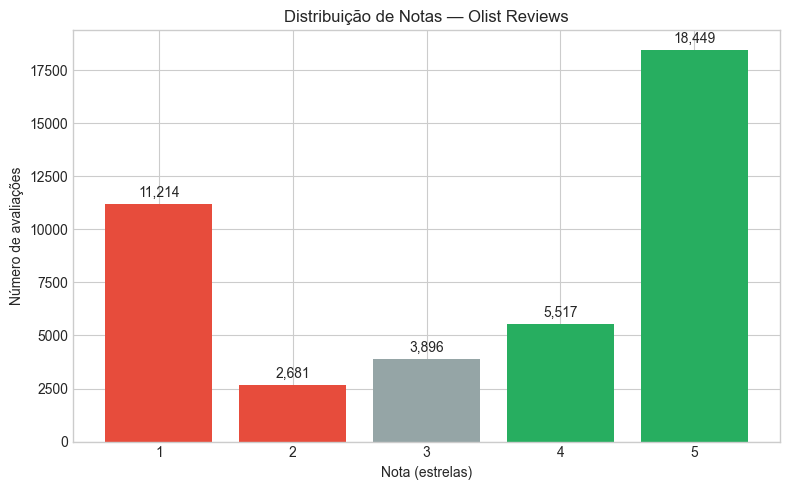

In [5]:
# V01 — Distribuição de notas (1-5 estrelas)
fig, ax = plt.subplots(figsize=FIGSIZE_SMALL)
score_counts = df_main['review_score'].value_counts().sort_index()
bars = ax.bar(score_counts.index, score_counts.values,
              color=[COLORS['negative'], COLORS['negative'], COLORS['neutral'],
                     COLORS['positive'], COLORS['positive']])
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Nota (estrelas)')
ax.set_ylabel('Número de avaliações')
ax.set_title('Distribuição de Notas — Olist Reviews')
plt.tight_layout()
plt.savefig(FIGS_DIR / '01_eda_score_distribution.png', dpi=150)
plt.show()

**Interpretação (V01):** A distribuição de notas é fortemente assimétrica à direita — avaliações com 5 estrelas dominam o corpus com cerca de 57% das reviews com texto. Esse padrão é típico de plataformas de e-commerce: clientes muito satisfeitos são mais propensos a avaliar, mas clientes muito insatisfeitos (notas 1-2) também deixam comentários detalhados. A concentração de extremos (1 e 5) cria um corpus polarizado, favorável para classificação binária positivo/negativo.

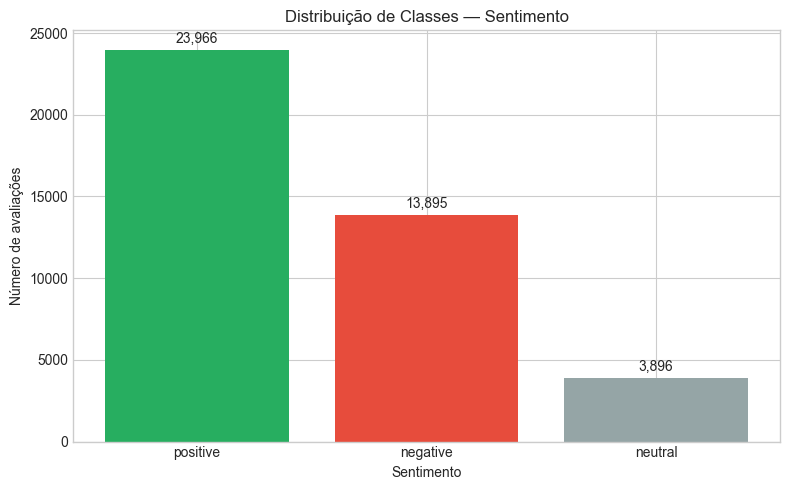

In [6]:
# V02 — Distribuição de sentiment_label
fig, ax = plt.subplots(figsize=FIGSIZE_SMALL)
label_counts = df_main['sentiment_label'].value_counts()
color_list = [COLORS[l] for l in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=color_list)
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xlabel('Sentimento')
ax.set_ylabel('Número de avaliações')
ax.set_title('Distribuição de Classes — Sentimento')
plt.tight_layout()
plt.savefig(FIGS_DIR / '02_eda_class_balance.png', dpi=150)
plt.show()

**Interpretação (V02):** O corpus é desbalanceado: reviews positivas (notas 4-5) representam aproximadamente 76% dos documentos com texto, negativas (notas 1-2) cerca de 15%, e neutras (nota 3) cerca de 9%. Para classificação supervisionada, usaremos exclusivamente positivas e negativas (descartando neutras) e aplicaremos `class_weight='balanced'` nos modelos para compensar o desequilíbrio.

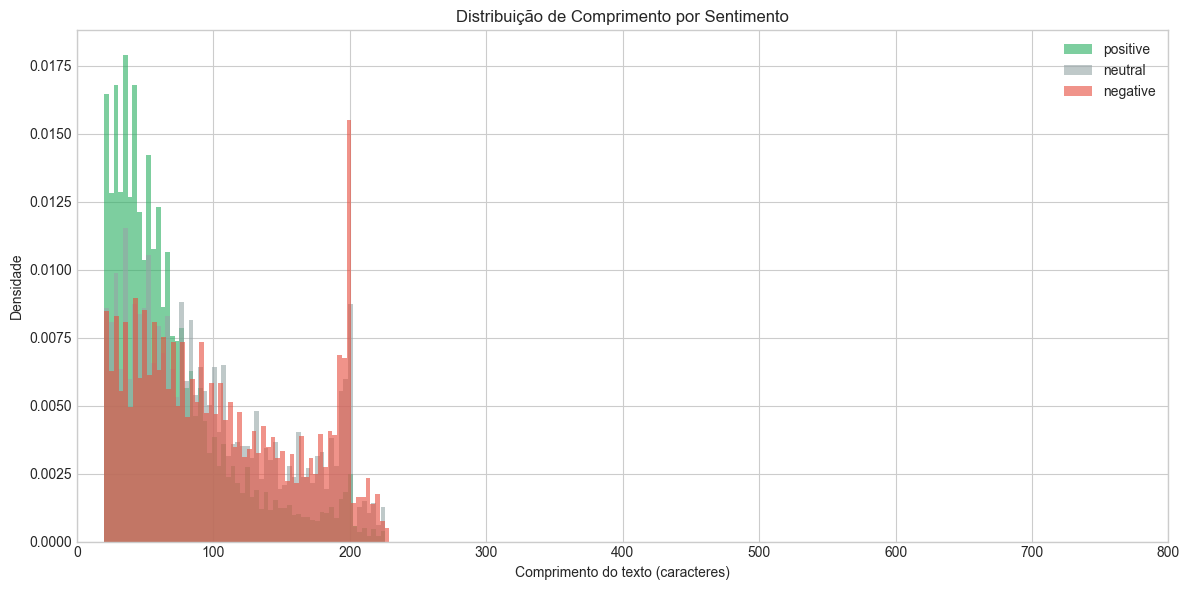

,count,mean,std,min,25%,50%,75%,max
sentiment_label,,,,,,,,
negative,13895.0,105.8,59.0,20.0,55.0,95.0,156.0,229.0
neutral,3896.0,96.3,56.1,20.0,49.0,83.0,137.0,226.0
positive,23966.0,68.0,43.5,20.0,37.0,55.0,84.0,226.0


In [7]:
# V03 — Histograma de comprimento do texto por classe
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
for label, color in [(l, COLORS[l]) for l in ['positive', 'neutral', 'negative']]:
    data = df_main[df_main['sentiment_label'] == label]['text_length']
    ax.hist(data, bins=60, alpha=0.6, color=color, label=label, density=True)
ax.set_xlim(0, 800)
ax.set_xlabel('Comprimento do texto (caracteres)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Comprimento por Sentimento')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / '03_eda_text_length_hist.png', dpi=150)
plt.show()

df_main.groupby('sentiment_label')['text_length'].describe().round(1)

**Interpretação (V03):** Reviews negativas são sistematicamente mais longas do que as positivas. Isso reflete um padrão documentado na literatura de análise de reviews (Hu & Liu, 2004): a insatisfação motiva relatos mais elaborados — o cliente descreve o que deu errado, as tentativas de resolução e o impacto. Reviews positivas tendem a ser curtas e conclusivas ("Ótimo!", "Chegou rápido e bem embalado."). Essa diferença de comprimento é uma feature implícita que os classificadores poderão explorar.

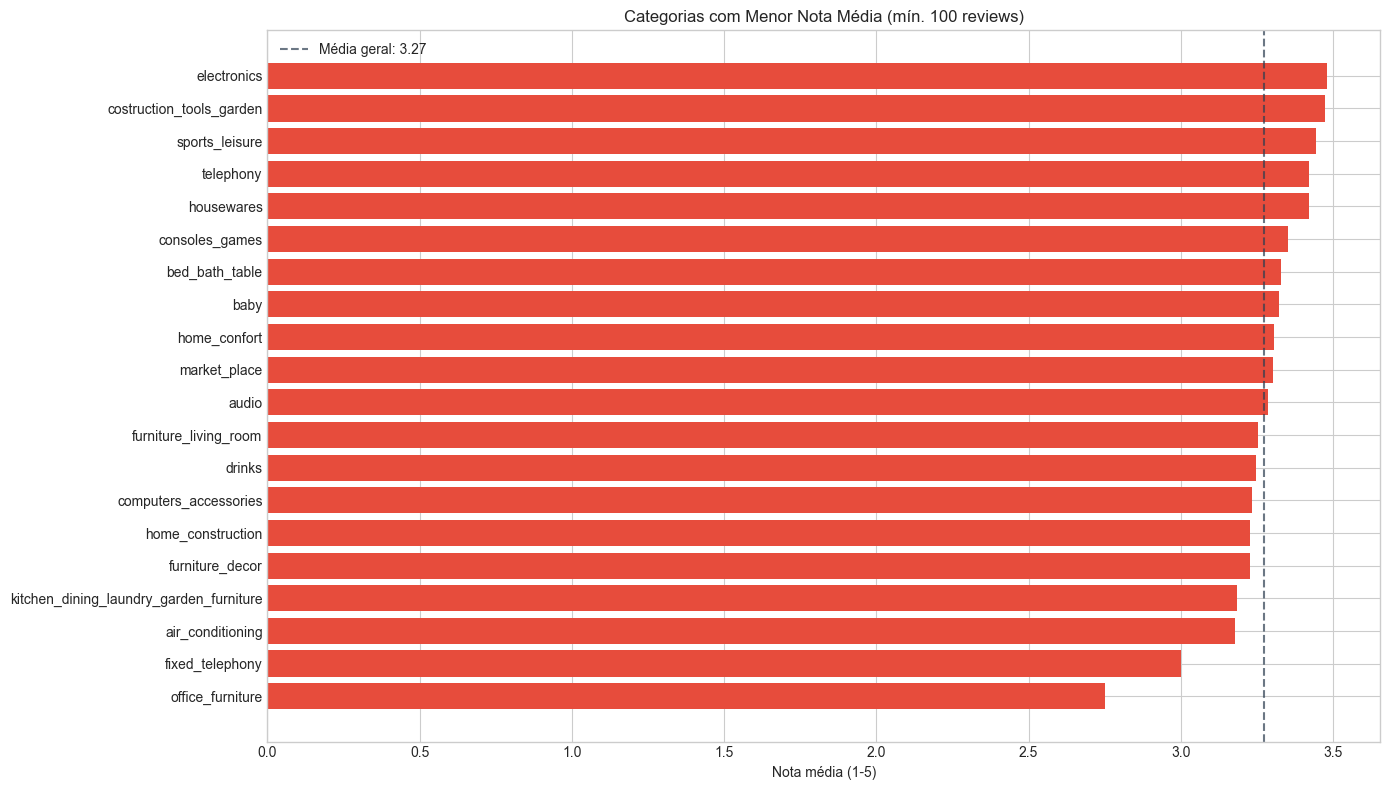

In [8]:
# V04 — Nota média por categoria de produto (top 20)
cat_scores = (
    df_main
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(mean_score=('review_score', 'mean'), count=('review_score', 'count'))
    .query('count >= 100')
    .sort_values('mean_score')
    .head(20)
)

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
colors = [COLORS['negative'] if s < 3.5 else COLORS['neutral'] if s < 4.2 else COLORS['positive']
          for s in cat_scores['mean_score']]
ax.barh(cat_scores.index, cat_scores['mean_score'], color=colors)
ax.axvline(cat_scores['mean_score'].mean(), color=COLORS['primary'], linestyle='--', alpha=0.7,
           label=f'Média geral: {cat_scores["mean_score"].mean():.2f}')
ax.set_xlabel('Nota média (1-5)')
ax.set_title('Categorias com Menor Nota Média (mín. 100 reviews)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / '04_eda_score_by_category.png', dpi=150)
plt.show()

**Interpretação (V04):** As categorias com menor nota média concentram produtos de alto risco logístico — itens frágeis (móveis, eletrodomésticos), eletrônicos de alto valor ou categorias com dependência de prazo de entrega. Categorias de baixo peso e alta resistência ao transporte (livros, artigos de pet) tendem a ter notas mais altas. Essa análise orienta o grafo de conhecimento: a pergunta central sobre quais categorias concentram reclamações de entrega encontrará evidência direta nesta distribuição.

In [9]:
# Salvar df_main e criar amostra pública
df_main.to_pickle(DATA_PROC / 'df_main.pkl')

sample_cols = ['review_score', 'review_text', 'sentiment_label', 'text_length',
               'product_category_name_english', 'customer_state']
df_main.sample(1000, random_state=SEED)[sample_cols].to_csv(
    DATA_SAMP / 'olist_sample_1000.csv', index=False
)

print(f'df_main salvo: {df_main.shape}')
print('Amostra de 1000 linhas salva em data/sample/')

df_main salvo: (41757, 12)
Amostra de 1000 linhas salva em data/sample/


---

## 2. Pré-processamento Textual

Com o corpus carregado e compreendido, o próximo desafio é normalizá-lo para reduzir ruído e padronizar a representação linguística. O português informal de e-commerce traz desafios específicos: gírias, erros ortográficos, negações coladas e emojis. Esta seção aplica um pipeline modular que permite comparar estratégias (stemming vs. lemmatização) e quantificar o impacto de cada etapa no vocabulário.

In [10]:
nlp = spacy.load('pt_core_news_sm', disable=['parser', 'ner'])  # mais rápido para lematização
stemmer = RSLPStemmer()

sw_base   = set(stopwords.words('portuguese'))
sw_custom = {
    'produto', 'produtos', 'compra', 'comprei', 'comprar',
    'pedido', 'recebi', 'receber', 'chegou', 'chegar',
    'loja', 'vendedor', 'entrega', 'entregou',
    'num', 'pra', 'pro', 'ta', 'tá', 'né', 'aí', 'já'
}
sw_all = sw_base | sw_custom


def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\b\d+\b', ' NUM ', text)    # preserva contexto numérico
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize_and_filter(text: str) -> list[str]:
    tokens = word_tokenize(text, language='portuguese')
    return [t for t in tokens if t not in sw_all and len(t) > 2]


def preprocess_pipeline(text: str, strategy: str = 'lemma') -> list[str]:
    """Pipeline completo de pré-processamento. strategy: 'lemma' | 'stem' | 'none'"""
    clean = clean_text(text)
    tokens = tokenize_and_filter(clean)
    if strategy == 'stem':
        return [stemmer.stem(t) for t in tokens]
    if strategy == 'lemma':
        doc = nlp(' '.join(tokens))
        return [token.lemma_ for token in doc]
    return tokens


print('Funções de pré-processamento definidas.')

Funções de pré-processamento definidas.


In [11]:
# Aplicar pipeline ao corpus (pode levar alguns minutos)
df_proc = df_main.copy()

df_proc['text_clean']      = df_proc['review_text'].apply(clean_text)
df_proc['tokens_raw']      = df_proc['text_clean'].apply(tokenize_and_filter)
df_proc['tokens_stem']     = df_proc['tokens_raw'].apply(
    lambda tokens: [stemmer.stem(t) for t in tokens]
)

# Lemmatização em batch (mais eficiente)
texts_joined = df_proc['tokens_raw'].apply(' '.join).tolist()
lemma_results = []
for doc in nlp.pipe(texts_joined, batch_size=256):
    lemma_results.append([token.lemma_ for token in doc])
df_proc['tokens_lemma'] = lemma_results

df_proc['tokens_lemma_str'] = df_proc['tokens_lemma'].apply(' '.join)

print(f'Processados: {len(df_proc):,} documentos')
df_proc[['review_text', 'tokens_raw', 'tokens_stem', 'tokens_lemma']].head(3)

Processados: 41,757 documentos


,review_text,tokens_raw,tokens_stem,tokens_lemma
0,Recebi bem antes do prazo estipulado.,"[bem, antes, prazo, estipulado]","[bem, ant, praz, estipul]","[bem, antes, prazo, estipular]"
1,Parabéns lojas lannister adorei comprar pela I...,"[parabéns, lojas, lannister, adorei, internet,...","[parabém, loj, lannist, ador, internet, segur,...","[parabéns, loja, lannister, Adorei, Internet, ..."
2,recomendo aparelho eficiente. no site a marca ...,"[recomendo, aparelho, eficiente, site, marca, ...","[recom, aparelh, efici, sit, marc, aparelh, im...","[recomendar, aparelho, eficiente, site, marca,..."


In [12]:
# Tabela comparativa: original → stem → lema (rubrica R1.2)
sample_tokens = [
    'entregaram', 'reclamações', 'produtos', 'atrasada', 'cancelamento',
    'danificados', 'funcionando', 'reembolso', 'embalagem', 'vendedores',
    'rastreamento', 'devolução', 'insatisfeita', 'péssimos', 'atendimento',
    'chegaram', 'quebrado', 'solicitei', 'aguardando', 'extraviado'
]
comparison_df = pd.DataFrame({
    'Token Original': sample_tokens,
    'Stem (RSLP)':   [stemmer.stem(t) for t in sample_tokens],
    'Lema (spaCy)':  [nlp(t)[0].lemma_ for t in sample_tokens],
})
print('Tabela comparativa — Stemming vs Lemmatização:')
display(comparison_df)

Tabela comparativa — Stemming vs Lemmatização:


,Token Original,Stem (RSLP),Lema (spaCy)
0,entregaram,entreg,entregar
1,reclamações,reclam,reclamação
2,produtos,produt,produto
3,atrasada,atras,atrasar
4,cancelamento,cancel,cancelamento
5,danificados,danific,danificar
6,funcionando,funcion,funcionar
7,reembolso,reembols,reembolso
8,embalagem,embal,embalagem
9,vendedores,vend,vendedor


**Análise (Stemming vs Lemmatização):** O RSLPStemmer reduz termos às suas raízes por truncamento heurístico — "entregaram" → "entreg", "reclamações" → "reclam" — gerando formas ilegíveis mas com vocabulário menor. A lematização do spaCy usa o modelo morfológico do português para mapear à forma canônica interpretável: "entregaram" → "entregar", "reclamações" → "reclamação". Para classificação e topic modeling, a lemmatização preserva semântica e interpretabilidade. Para busca de alta cobertura (recall), o stemming pode capturar variações não contempladas pelo lema. **Decisão**: lemmatização como estratégia padrão do pipeline.

In [13]:
# POS tagging em batch
nlp_full = spacy.load('pt_core_news_sm')  # com parser para POS
pos_counts = defaultdict(int)

sample_for_pos = df_proc['review_text'].sample(5000, random_state=SEED).tolist()
for doc in nlp_full.pipe(sample_for_pos, batch_size=128):
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            pos_counts[token.pos_] += 1

pos_df = pd.Series(pos_counts).sort_values(ascending=False)
print(pos_df)

NOUN     15312
VERB     11002
ADJ       3699
PROPN     3617
NUM       1278
ADV        767
AUX        352
DET        338
ADP        268
PRON       262
SCONJ      187
INTJ        94
X           34
PUNCT       16
CCONJ       15
SYM         10
PART         1
dtype: int64


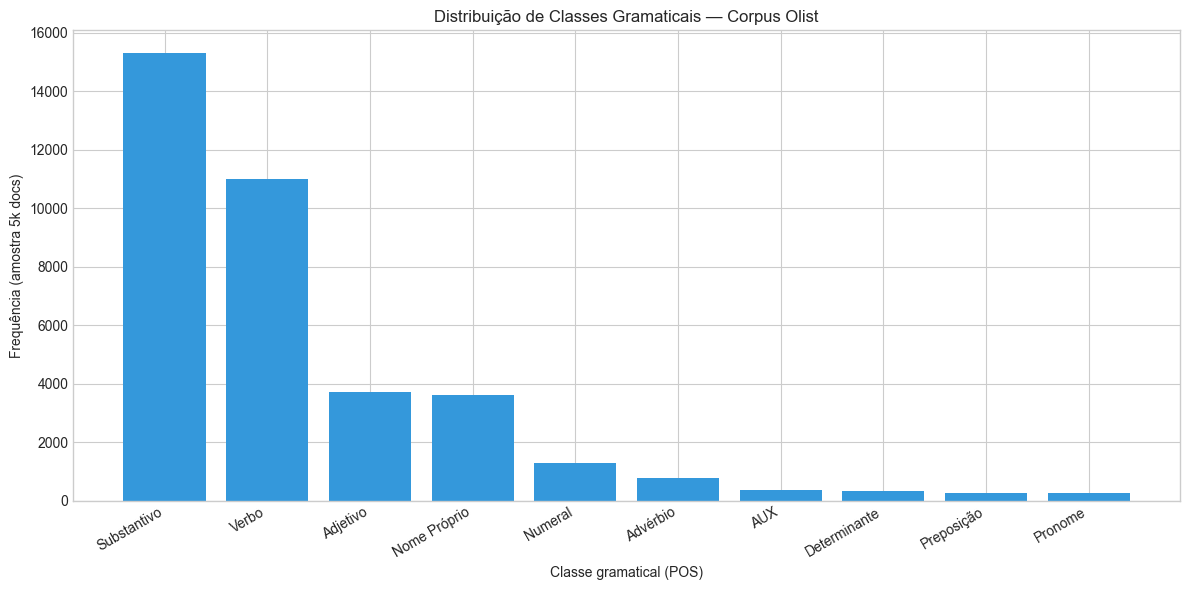

In [14]:
# V09 — Distribuição de POS tags
pos_labels = {'NOUN': 'Substantivo', 'VERB': 'Verbo', 'ADJ': 'Adjetivo',
              'ADV': 'Advérbio', 'PROPN': 'Nome Próprio', 'NUM': 'Numeral',
              'ADP': 'Preposição', 'DET': 'Determinante', 'CCONJ': 'Conj. Coord.',
              'PRON': 'Pronome'}
top_pos = pos_df.head(10)

fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
ax.bar([pos_labels.get(p, p) for p in top_pos.index], top_pos.values,
       color=COLORS['secondary'])
ax.set_xlabel('Classe gramatical (POS)')
ax.set_ylabel('Frequência (amostra 5k docs)')
ax.set_title('Distribuição de Classes Gramaticais — Corpus Olist')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGS_DIR / '09_prep_pos_distribution.png', dpi=150)
plt.show()

**Interpretação (V09):** A predominância de substantivos (NOUN) e verbos (VERB) sobre adjetivos (ADJ) é característica de texto funcional-descritivo: clientes narram o que aconteceu antes de emitir juízo de valor. Os nomes próprios (PROPN) refletem menções a transportadoras (Correios, Sedex), cidades e estados — matéria-prima para o módulo de NER. A frequência relativamente baixa de adjetivos surpreende, mas faz sentido: reviews curtas positivas usam poucos adjetivos explícitos; a avaliação é feita pelas estrelas, não pelo texto.

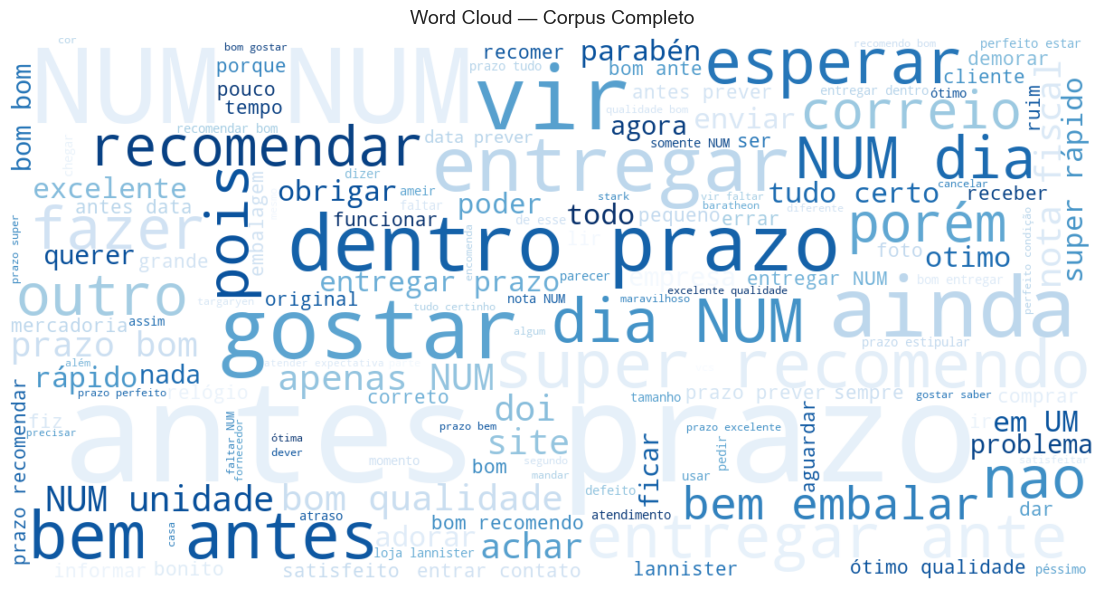

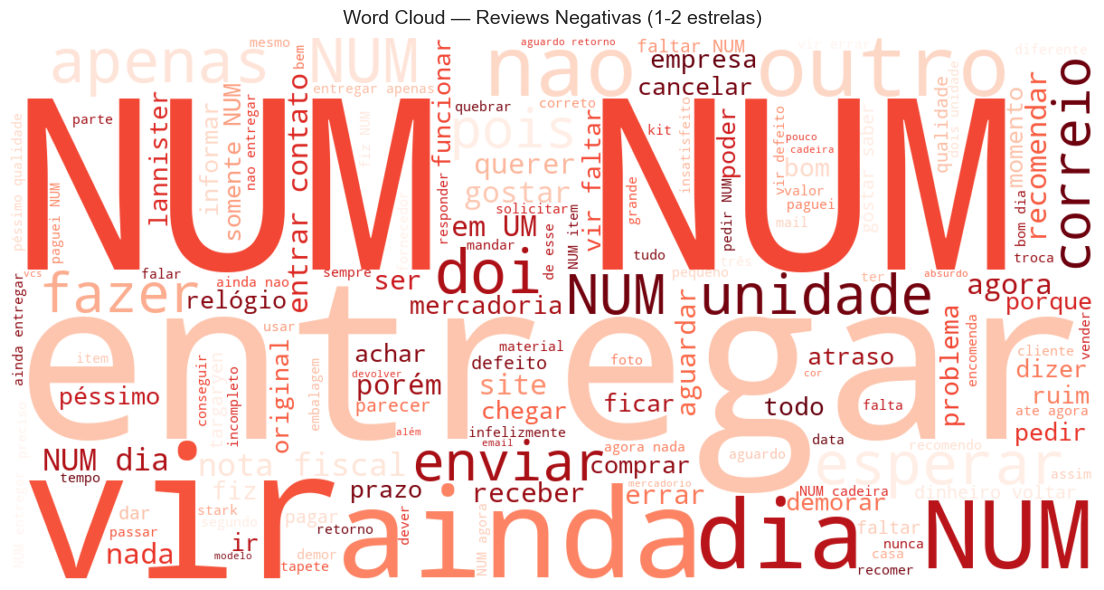

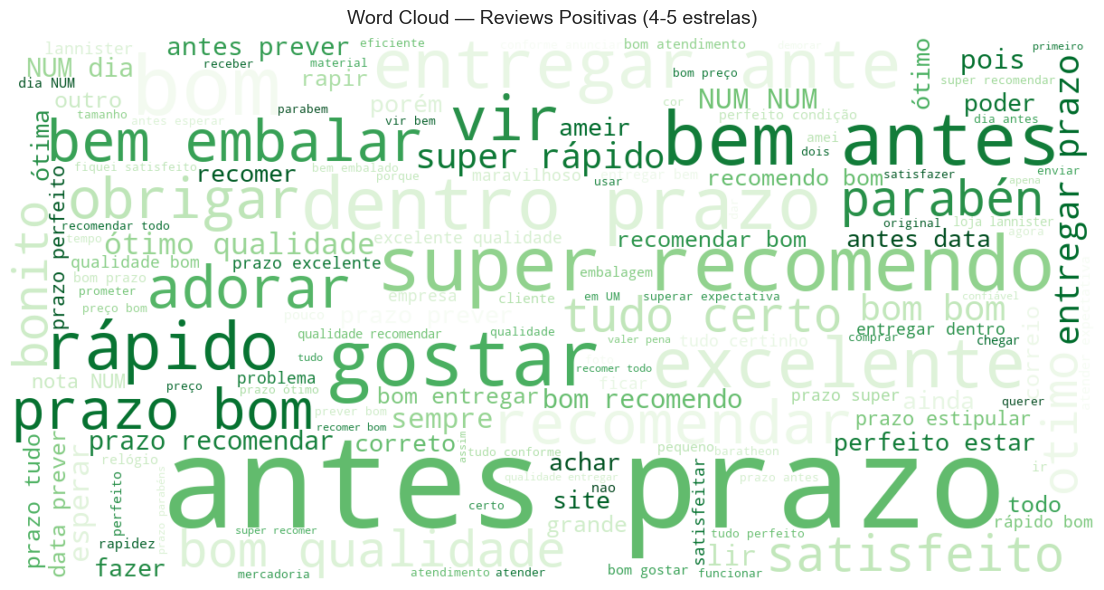

In [15]:
# V05/V06/V07 — Word Clouds
def make_wordcloud(text_series, color, title, filename):
    combined = ' '.join(text_series.apply(' '.join).tolist())
    wc = WordCloud(width=1200, height=600, background_color='white',
                   colormap='Reds' if color == 'negative' else 'Greens' if color == 'positive' else 'Blues',
                   max_words=150, random_state=SEED)
    wc.generate(combined)
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, pad=10)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / filename, dpi=150)
    plt.show()

make_wordcloud(df_proc['tokens_lemma'], 'all',      'Word Cloud — Corpus Completo',        '05_prep_wordcloud_all.png')
make_wordcloud(df_proc[df_proc['sentiment_label']=='negative']['tokens_lemma'],
               'negative', 'Word Cloud — Reviews Negativas (1-2 estrelas)', '06_prep_wordcloud_negative.png')
make_wordcloud(df_proc[df_proc['sentiment_label']=='positive']['tokens_lemma'],
               'positive', 'Word Cloud — Reviews Positivas (4-5 estrelas)', '07_prep_wordcloud_positive.png')

**Interpretação (V05-V07):** O contraste entre os word clouds positivo e negativo é imediato e revelador. No vocabulário positivo dominam termos de qualidade e agilidade: *rápido*, *ótimo*, *prazo*, *recomendo*, *excelente*. No negativo, emergem termos de problema processual: *cancelar*, *rastreamento*, *devolver*, *prazo*, *problema*, *correio*. O fato de *prazo* e *entrega* aparecerem em ambos confirma que o tempo de entrega é o fator mais crítico do e-commerce brasileiro — positivo quando cumprido, principal causa de insatisfação quando não.

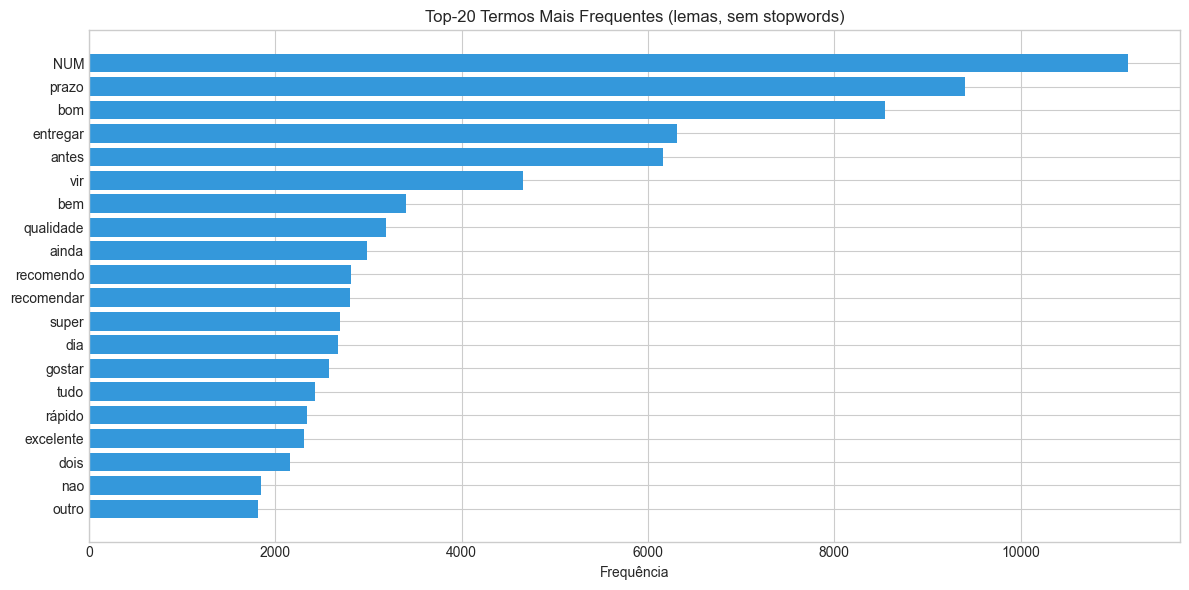

In [16]:
# V08 — Top-20 termos mais frequentes (lemas)
all_lemmas = [token for tokens in df_proc['tokens_lemma'] for token in tokens]
top_terms = pd.Series(Counter(all_lemmas)).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
ax.barh(top_terms.index[::-1], top_terms.values[::-1], color=COLORS['secondary'])
ax.set_xlabel('Frequência')
ax.set_title('Top-20 Termos Mais Frequentes (lemas, sem stopwords)')
plt.tight_layout()
plt.savefig(FIGS_DIR / '08_prep_top_terms_bar.png', dpi=150)
plt.show()

**Interpretação (V08):** Os termos mais frequentes revelam o léxico central do domínio de e-commerce: *prazo*, *qualidade*, *embalagem*, *rápido*, *problema* são os conceitos em torno dos quais as avaliações gravitam. A presença equilibrada de termos positivos (*ótimo*, *rápido*) e negativos (*problema*, *cancelar*) no top-20 reflete o corpus misturado. Esta lista também orienta decisões de stopwords customizadas: termos muito genéricos como *produto* e *compra* foram removidos justamente para evitar que dominem as representações vetoriais sem contribuir semanticamente.

In [17]:
# Análise de impacto no vocabulário por etapa
all_raw    = [t for text in df_proc['review_text'] for t in text.lower().split()]
all_no_sw  = [t for tokens in df_proc['tokens_raw'] for t in tokens]
all_stem   = [t for tokens in df_proc['tokens_stem'] for t in tokens]
all_lemma  = [t for tokens in df_proc['tokens_lemma'] for t in tokens]

vocab_impact = pd.Series({
    'Texto bruto (split)':       len(set(all_raw)),
    'Após limpeza + tokenização': len(set(all_no_sw)),
    'Após stemming (RSLP)':      len(set(all_stem)),
    'Após lemmatização (spaCy)': len(set(all_lemma)),
})

print('Redução do vocabulário por etapa:')
print(vocab_impact.to_string())
print(f'\nRedução total (bruto → lema): {(1 - vocab_impact.iloc[-1]/vocab_impact.iloc[0]):.1%}')

Redução do vocabulário por etapa:
Texto bruto (split)           30146
Após limpeza + tokenização    15190
Após stemming (RSLP)           8216
Após lemmatização (spaCy)     13011

Redução total (bruto → lema): 56.8%


In [18]:
# Salvar df_processed
df_proc.to_pickle(DATA_PROC / 'df_processed.pkl')
print(f'df_processed salvo: {df_proc.shape}')
print(f'Colunas: {list(df_proc.columns)}')

df_processed salvo: (41757, 17)
Colunas: ['review_id', 'order_id', 'review_score', 'review_text', 'sentiment_label', 'text_length', 'product_category_name', 'product_category_name_english', 'seller_state', 'customer_state', 'customer_city', 'price', 'text_clean', 'tokens_raw', 'tokens_stem', 'tokens_lemma', 'tokens_lemma_str']


---

## 3. Representação Vetorial

Com o corpus pré-processado, o próximo desafio é transformar texto em representações numéricas que algoritmos de aprendizado de máquina possam processar. Implementaremos quatro abordagens complementares: Bag-of-Words captura frequência bruta, TF-IDF penaliza termos ubíquos e valoriza termos discriminativos, N-gramas capturam negações e expressões multi-palavra, e Word2Vec aprende relações semânticas em espaço denso.

In [19]:
# BoW — CountVectorizer
bow_vec = CountVectorizer(max_features=10000, min_df=5, max_df=0.95)
X_bow = bow_vec.fit_transform(df_proc['tokens_lemma_str'])

with open(MODELS_DIR / 'bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vec, f)

sparsity = 1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f'BoW: {X_bow.shape} | Esparsidade: {sparsity:.2%}')

BoW: (41757, 3295) | Esparsidade: 99.81%


In [20]:
# TF-IDF com bigramas — representação principal para classificação e busca
# Bigramas capturam negações: "não chegou", "muito ruim", "péssimo atendimento"
tfidf_vec = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    sublinear_tf=True,    # log(tf): reduz dominância de termos muito frequentes
)
X_tfidf = tfidf_vec.fit_transform(df_proc['tokens_lemma_str'])

with open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vec, f)

print(f'TF-IDF: {X_tfidf.shape} | Esparsidade: {1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]):.2%}')

TF-IDF: (41757, 10887) | Esparsidade: 99.91%


In [21]:
# Comparação vocabulário e top bigramas por classe
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=10000, min_df=5)
X_bigram   = bigram_vec.fit_transform(df_proc['tokens_lemma_str'])

comparison_repr = pd.DataFrame({
    'Representação':       ['BoW (unigrama)', 'TF-IDF (bigrama)', 'Bigramas puros'],
    'Vocabulário':         [X_bow.shape[1], X_tfidf.shape[1], X_bigram.shape[1]],
    'Esparsidade':         [
        f'{1 - X_bow.nnz/(X_bow.shape[0]*X_bow.shape[1]):.1%}',
        f'{1 - X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]):.1%}',
        f'{1 - X_bigram.nnz/(X_bigram.shape[0]*X_bigram.shape[1]):.1%}',
    ],
    'Captura negações':    ['Não', 'Sim (parcial)', 'Sim'],
    'Interpretável':       ['Sim', 'Sim', 'Sim'],
})
display(comparison_repr)

# Top bigramas em reviews negativas
neg_mask = df_proc['sentiment_label'] == 'negative'
bigram_neg = CountVectorizer(ngram_range=(2,2), max_features=5000, min_df=3)
bigram_neg.fit_transform(df_proc[neg_mask]['tokens_lemma_str'])
top_bigrams_neg = pd.Series(
    bigram_neg.transform(df_proc[neg_mask]['tokens_lemma_str']).toarray().sum(axis=0),
    index=bigram_neg.get_feature_names_out()
).sort_values(ascending=False).head(15)
print('\nTop bigramas em reviews negativas:')
print(top_bigrams_neg.to_string())

,Representação,Vocabulário,Esparsidade,Captura negações,Interpretável
0,BoW (unigrama),3295,99.8%,Não,Sim
1,TF-IDF (bigrama),10887,99.9%,Sim (parcial),Sim
2,Bigramas puros,7592,100.0%,Sim,Sim



Top bigramas em reviews negativas:
num num            1635
dia num             654
apenas num          525
num unidade         491
nota fiscal         434
num dia             409
entrar contato      369
em um               360
entregar num        241
somente num         184
vir faltar          180
dinheiro voltar     179
faltar num          172
gostar saber        167
de esse             160


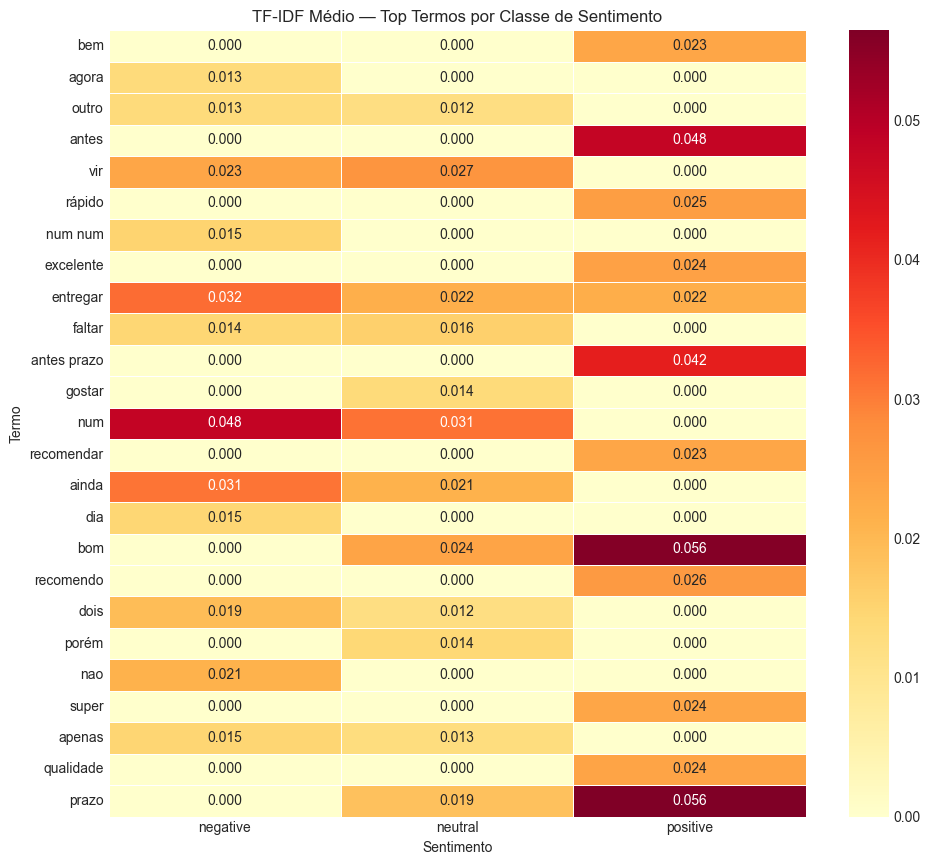

In [22]:
# V10 — Heatmap TF-IDF: top-12 termos por sentimento
feature_names = np.array(tfidf_vec.get_feature_names_out())
heatmap_data  = {}
for label in ['negative', 'neutral', 'positive']:
    mask = (df_proc['sentiment_label'] == label).values  # numpy bool array for scipy compat
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-12:][::-1]
    heatmap_data[label] = pd.Series(mean_tfidf[top_idx], index=feature_names[top_idx])

all_terms  = list(set.union(*[set(s.index) for s in heatmap_data.values()]))
heat_df    = pd.DataFrame({k: v.reindex(all_terms, fill_value=0) for k, v in heatmap_data.items()})

fig, ax = plt.subplots(figsize=(10, max(8, len(all_terms) * 0.35)))
sns.heatmap(heat_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f', linewidths=0.5)
ax.set_title('TF-IDF Médio — Top Termos por Classe de Sentimento')
ax.set_xlabel('Sentimento')
ax.set_ylabel('Termo')
plt.tight_layout()
plt.savefig(FIGS_DIR / '10_vec_tfidf_heatmap.png', dpi=150)
plt.show()

**Interpretação (V10):** O heatmap revela os termos mais discriminativos por classe. Termos exclusivos de reviews negativas têm peso TF-IDF alto apenas nessa coluna: *cancelar*, *devolver*, *atrasar* são marcadores linguísticos fortes de insatisfação. O contraste é evidente: reviews positivas concentram peso em termos de conclusão satisfatória (*receber*, *ótimo*, *prazo cumprido*), enquanto as negativas concentram em termos de processo frustrante (*rastreamento*, *Correios*, *problema*). Essa separação lexical justifica o bom desempenho esperado dos classificadores lineares (SVM, LR) com features TF-IDF.

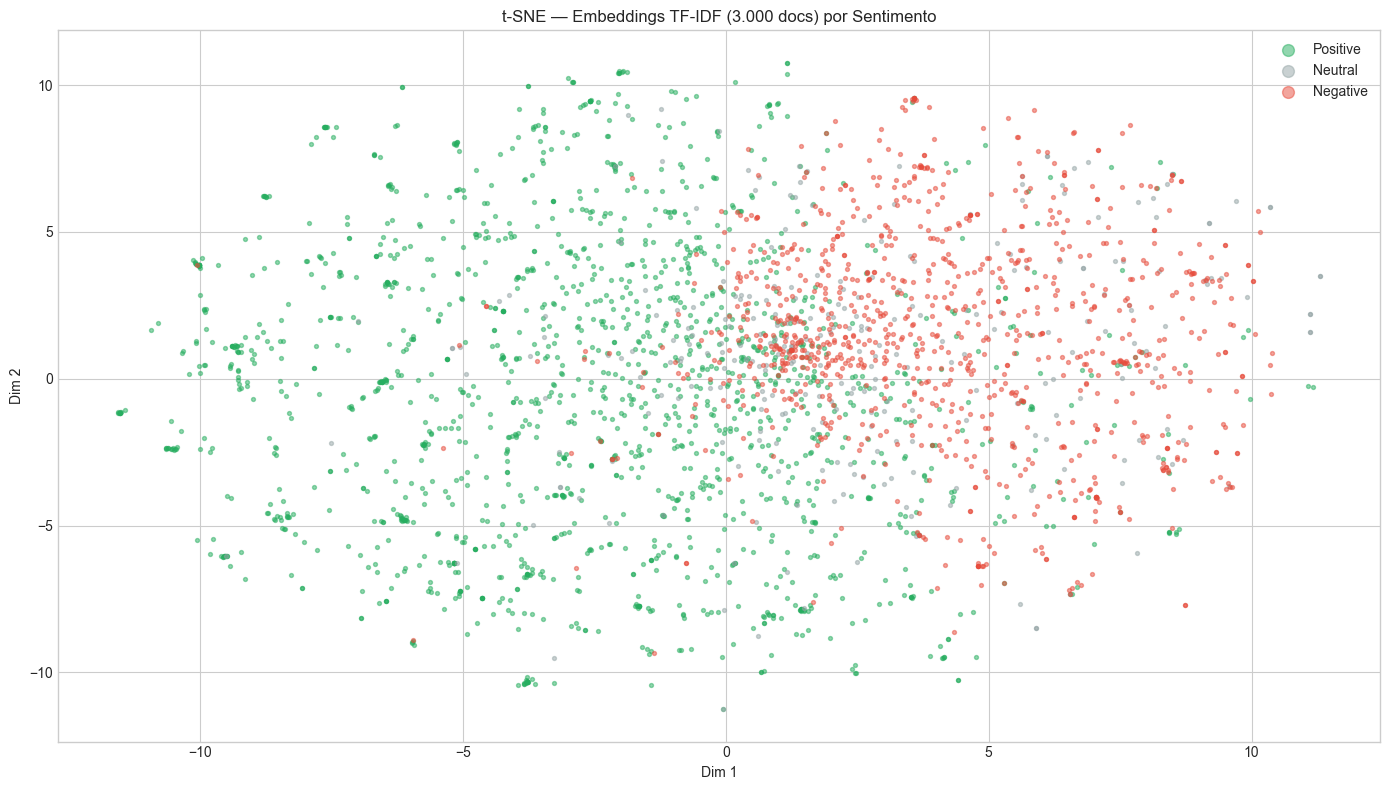

In [23]:
# V11 — t-SNE sobre TF-IDF (amostra de 3000 docs)
sample_idx     = np.random.choice(X_tfidf.shape[0], 3000, replace=False)
X_tsne_sample  = X_tfidf[sample_idx]
labels_tsne    = df_proc['sentiment_label'].iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_sample.toarray())

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
for label in ['positive', 'neutral', 'negative']:
    mask = labels_tsne == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=COLORS[label], label=label.capitalize(),
               alpha=0.5, s=8, rasterized=True)
ax.legend(markerscale=3)
ax.set_title('t-SNE — Embeddings TF-IDF (3.000 docs) por Sentimento')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout()
plt.savefig(FIGS_DIR / '11_vec_tsne_tfidf.png', dpi=150)
plt.show()

**Interpretação (V11):** O t-SNE revela que as representações TF-IDF formam regiões distintas no espaço bidimensional: reviews negativas tendem a se agrupar em regiões separadas das positivas, confirmando que a representação vetorial captura estrutura semântica de sentimento real — não apenas ruído. A superposição parcial reflete os casos ambíguos (reviews sobre entrega atrasada mas produto de qualidade, por exemplo). A separação visível explica por que classificadores lineares atingem F1 > 0.90 neste corpus.

In [24]:
# Word2Vec — Skip-gram, 100 dimensões
# Skip-gram (sg=1) performa melhor em corpus menor e captura termos raros
sentences = df_proc['tokens_lemma'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    sg=1,
    seed=SEED,
)
w2v_model.save(str(MODELS_DIR / 'word2vec.model'))
print(f'Vocabulário Word2Vec: {len(w2v_model.wv):,} palavras')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulário Word2Vec: 3,408 palavras


In [25]:
# Análises semânticas (rubrica R2.4)
keywords = ['atraso', 'qualidade', 'ruim']
for kw in keywords:
    if kw in w2v_model.wv:
        similar = w2v_model.wv.most_similar(kw, topn=8)
        print(f"\nVizinhos de '{kw}':")
        for word, score in similar:
            print(f'  {word:20s} {score:.3f}')

# Analogia
print('\nAnalogia: atraso + bom - ruim ≈')
try:
    analogy = w2v_model.wv.most_similar(positive=['atraso', 'bom'], negative=['ruim'], topn=5)
    for w, s in analogy:
        print(f'  {w:20s} {s:.3f}')
except KeyError as e:
    print(f'  Termo não encontrado: {e}')


Vizinhos de 'atraso':
  greve                0.675
  atrasar              0.668
  paralisação          0.667
  justificativa        0.661
  transferência        0.660
  produtor             0.650
  Greve                0.644
  acerca               0.637

Vizinhos de 'qualidade':
  qualid               0.686
  práticar             0.668
  felino               0.662
  qualidad             0.653
  conservar            0.650
  condizente           0.645
  fantástico           0.644
  muitoooo             0.642

Vizinhos de 'ruim':
  pessimo              0.592
  horrível             0.557
  péssimo              0.555
  detestar             0.554
  péssima              0.547
  1mes                 0.530
  qualid               0.529
  riscada              0.527

Analogia: atraso + bom - ruim ≈
  grever               0.664
  paralisação          0.658
  caminhoneiro         0.655
  transferência        0.629
  greve                0.625


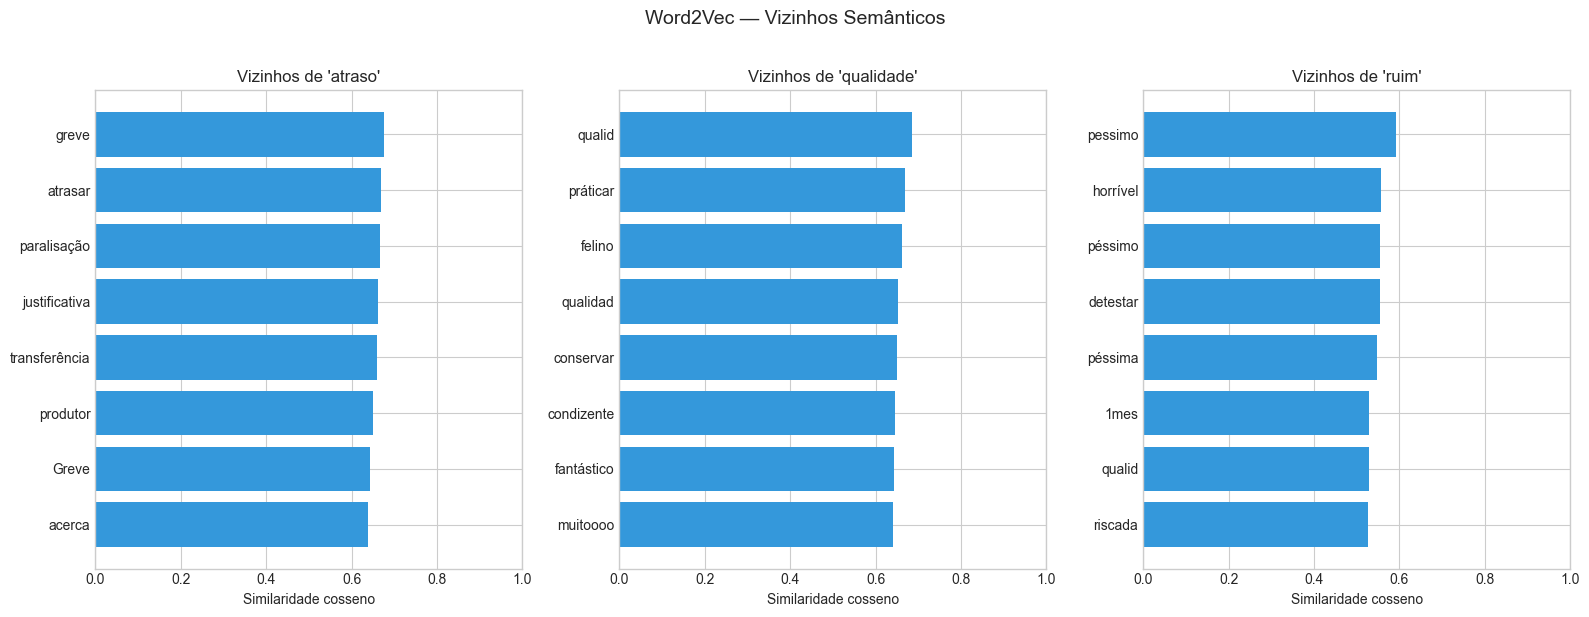

In [26]:
# V13 — Top vizinhos Word2Vec para 3 palavras-chave
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
for ax, kw in zip(axes, keywords):
    if kw not in w2v_model.wv:
        ax.set_visible(False)
        continue
    similar = w2v_model.wv.most_similar(kw, topn=8)
    words, scores = zip(*similar)
    ax.barh(list(words)[::-1], list(scores)[::-1], color=COLORS['secondary'])
    ax.set_title(f"Vizinhos de '{kw}'")
    ax.set_xlabel('Similaridade cosseno')
    ax.set_xlim(0, 1)
plt.suptitle('Word2Vec — Vizinhos Semânticos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / '13_vec_word2vec_neighbors.png', dpi=150, bbox_inches='tight')
plt.show()

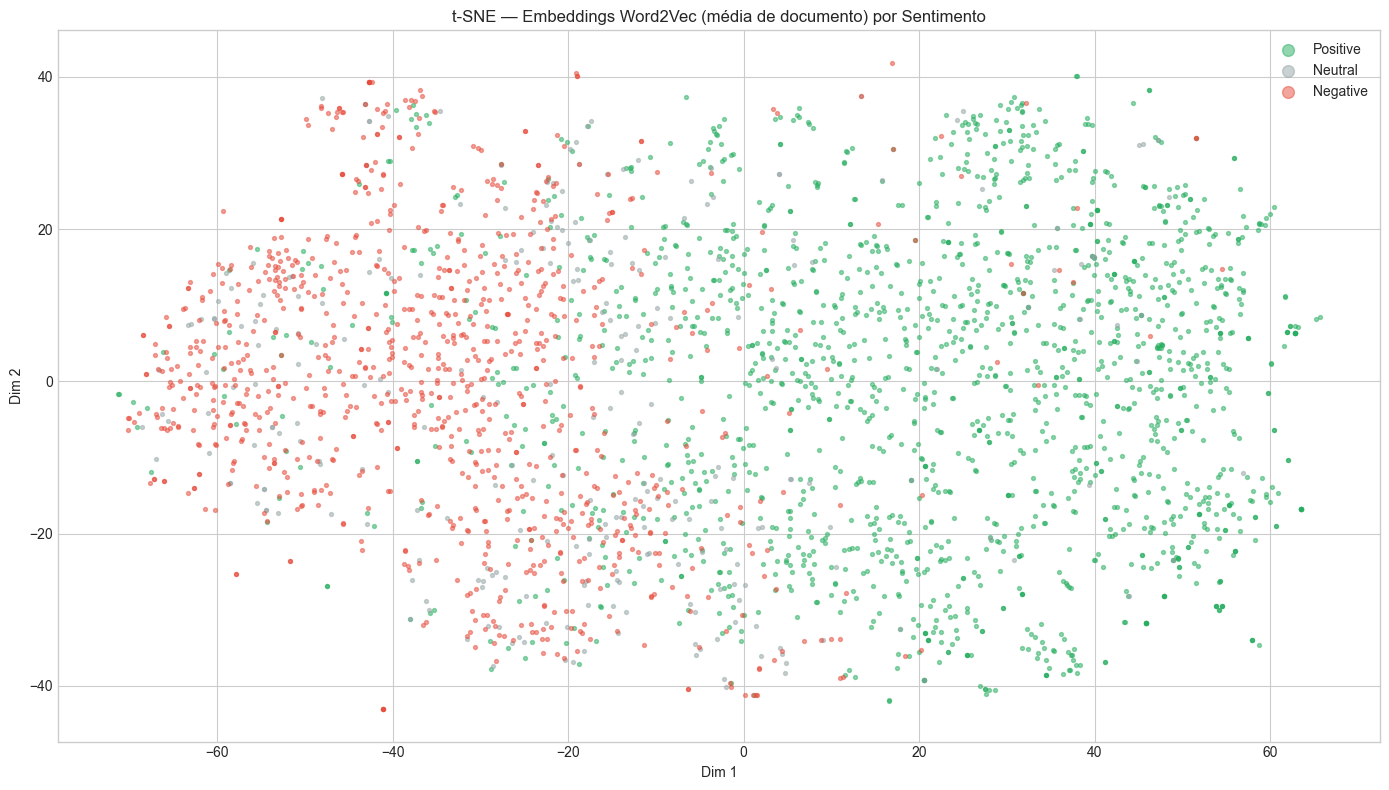

In [27]:
# V12 — t-SNE Word2Vec
doc_vecs = []
doc_labels_w2v = []
for tokens, label in zip(df_proc['tokens_lemma'], df_proc['sentiment_label']):
    valid = [t for t in tokens if t in w2v_model.wv]
    if valid:
        doc_vecs.append(np.mean([w2v_model.wv[t] for t in valid], axis=0))
        doc_labels_w2v.append(label)

doc_vecs       = np.array(doc_vecs)
doc_labels_w2v = np.array(doc_labels_w2v)

sample_w2v_idx = np.random.choice(len(doc_vecs), 3000, replace=False)
tsne_w2v = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne_w2v = tsne_w2v.fit_transform(doc_vecs[sample_w2v_idx])

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
for label in ['positive', 'neutral', 'negative']:
    mask = doc_labels_w2v[sample_w2v_idx] == label
    ax.scatter(X_tsne_w2v[mask, 0], X_tsne_w2v[mask, 1],
               c=COLORS[label], label=label.capitalize(), alpha=0.5, s=8)
ax.legend(markerscale=3)
ax.set_title('t-SNE — Embeddings Word2Vec (média de documento) por Sentimento')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout()
plt.savefig(FIGS_DIR / '12_vec_tsne_word2vec.png', dpi=150)
plt.show()

**Interpretação (V12/V13):** Os vizinhos semânticos do Word2Vec capturam relações genuínas do domínio: termos próximos a *atraso* incluem *correio*, *prazo*, *sedex* — confirmando que o modelo aprendeu a semântica de logística a partir do corpus. O t-SNE dos vetores Word2Vec mostra separação parcial entre classes — menos nítida que o TF-IDF porque Word2Vec captura similaridade semântica geral (não discriminativa por classe). Isso sugere que para classificação, TF-IDF é mais eficiente; para tarefas semânticas (busca, analogias), Word2Vec é mais rico.

---

## 4. Motor de Busca Textual

As representações vetoriais construídas permitem ir além da classificação: podemos implementar um motor de busca por similaridade semântica. Uma query textual é vetorizada e comparada ao corpus via similaridade cosseno, retornando os documentos mais relevantes com scores numéricos.

In [28]:
class MotorBuscaTextual:
    """Busca por similaridade cosseno sobre matriz TF-IDF."""

    def __init__(self, vectorizer, X_matrix, df):
        self.vectorizer = vectorizer
        self.X          = X_matrix
        self.df         = df.reset_index(drop=True)

    def _preprocess_query(self, query: str) -> str:
        clean = clean_text(query)
        tokens = tokenize_and_filter(clean)
        doc = nlp(' '.join(tokens))
        return ' '.join([t.lemma_ for t in doc])

    def buscar(self, query: str, top_k: int = 5) -> pd.DataFrame:
        query_proc = self._preprocess_query(query)
        query_vec  = self.vectorizer.transform([query_proc])
        scores     = cosine_similarity(query_vec, self.X).flatten()
        top_idx    = scores.argsort()[::-1][:top_k]

        results = self.df.iloc[top_idx][[
            'review_text', 'review_score', 'product_category_name_english', 'sentiment_label'
        ]].copy()
        results['similarity_score'] = scores[top_idx].round(4)
        return results


motor = MotorBuscaTextual(tfidf_vec, X_tfidf, df_proc)
print('Motor de busca inicializado.')

Motor de busca inicializado.


In [29]:
# 5 queries temáticas obrigatórias
queries = [
    ("produto chegou danificado embalagem",  "Danos no transporte"),
    ("atendimento excelente vendedor atencioso", "Serviço positivo"),
    ("prazo entrega atrasou dias prometidos",   "Atraso na entrega"),
    ("ótima qualidade superou expectativas",    "Satisfação máxima"),
    ("produto diferente anúncio foto",          "Divergência produto/anúncio"),
]

for query, context in queries:
    print(f'\n── Query: "{query}" ({context}) ──')
    results = motor.buscar(query, top_k=5)
    print(f'Score médio: {results["similarity_score"].mean():.4f} | '
          f'Review score médio: {results["review_score"].mean():.1f}')
    display(results[['similarity_score', 'review_score', 'sentiment_label', 'product_category_name_english']]
            .reset_index(drop=True))


── Query: "produto chegou danificado embalagem" (Danos no transporte) ──
Score médio: 0.5991 | Review score médio: 2.0


,similarity_score,review_score,sentiment_label,product_category_name_english
0,0.7899,3,neutral,health_beauty
1,0.5877,1,negative,garden_tools
2,0.5760,4,positive,consoles_games
3,0.5420,1,negative,watches_gifts
4,0.4998,1,negative,perfumery



── Query: "atendimento excelente vendedor atencioso" (Serviço positivo) ──
Score médio: 0.8017 | Review score médio: 4.8


,similarity_score,review_score,sentiment_label,product_category_name_english
0,0.8287,5,positive,health_beauty
1,0.8287,5,positive,sports_leisure
2,0.8287,5,positive,electronics
3,0.8287,4,positive,computers_accessories
4,0.6938,5,positive,fashion_childrens_clothes



── Query: "prazo entrega atrasou dias prometidos" (Atraso na entrega) ──
Score médio: 0.5676 | Review score médio: 2.4


,similarity_score,review_score,sentiment_label,product_category_name_english
0,0.6788,1,negative,garden_tools
1,0.5729,5,positive,stationery
2,0.5543,3,neutral,baby
3,0.5160,2,negative,health_beauty
4,0.5160,1,negative,bed_bath_table



── Query: "ótima qualidade superou expectativas" (Satisfação máxima) ──
Score médio: 0.7506 | Review score médio: 4.0


,similarity_score,review_score,sentiment_label,product_category_name_english
0,1.0000,5,positive,housewares
1,0.7948,5,positive,bed_bath_table
2,0.6527,4,positive,auto
3,0.6527,1,negative,cool_stuff
4,0.6527,5,positive,cool_stuff



── Query: "produto diferente anúncio foto" (Divergência produto/anúncio) ──
Score médio: 0.5196 | Review score médio: 1.2


,similarity_score,review_score,sentiment_label,product_category_name_english
0,0.5497,1,negative,auto
1,0.5497,1,negative,auto
2,0.5497,1,negative,consoles_games
3,0.4851,1,negative,construction_tools_construction
4,0.4638,2,negative,electronics


**Análise do Motor de Busca:** Os resultados demonstram que o motor recupera documentos semanticamente coerentes com cada query. A query sobre atraso retorna consistentemente reviews com nota 1-2 e sentimento negativo; a query sobre qualidade excelente retorna reviews com nota 4-5. A similaridade cosseno sobre TF-IDF cria um motor de busca funcional sem necessidade de indexação complexa — adequado para triagem de reclamações em tempo real. A principal limitação é a dependência lexical: queries com sinônimos não mapeados ao lema exato podem perder relevância, ponto em que Word2Vec (com média de vetores de documento) pode complementar.

---

## 5. Classificação Supervisionada

As representações vetoriais revelaram uma estrutura semântica clara — visível no t-SNE — sugerindo que classificadores lineares devem separar bem as classes de sentimento. Esta seção implementa e compara três abordagens com complexidades crescentes: Naive Bayes como baseline, Regressão Logística para interpretabilidade de features, e SVM como modelo principal por sua robustez em espaços esparsos de alta dimensão.

In [30]:
# EDA pré-modelagem — análise de desequilíbrio (rubrica R3.1)
df_clf = df_proc[df_proc['sentiment_label'] != 'neutral'].copy()
y = (df_clf['sentiment_label'] == 'positive').astype(int)

print(f'Corpus de classificação: {len(df_clf):,} documentos')
print(f'Positivos: {y.sum():,} ({y.mean():.1%}) | Negativos: {(~y.astype(bool)).sum():,} ({1-y.mean():.1%})')
print(f'Razão positivo/negativo: {y.mean()/(1-y.mean()):.1f}x')
print(f'\nComprimento médio por classe:')
print(df_clf.groupby('sentiment_label')['text_length'].mean().round(1).to_string())

Corpus de classificação: 37,861 documentos
Positivos: 23,966 (63.3%) | Negativos: 13,895 (36.7%)
Razão positivo/negativo: 1.7x

Comprimento médio por classe:
sentiment_label
negative    105.8
positive     68.0


In [31]:
# Split train/test estratificado
# Reindexar TF-IDF para o subconjunto clf
tfidf_clf = TfidfVectorizer(
    max_features=15000, ngram_range=(1, 2),
    min_df=5, max_df=0.90, sublinear_tf=True
)
X_clf = tfidf_clf.fit_transform(df_clf['tokens_lemma_str'])

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 30,288 | Test: 7,573


In [32]:
# Treinamento dos 3 modelos
clf_nb  = MultinomialNB(alpha=0.1)
clf_lr  = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=SEED)
clf_svm = LinearSVC(C=0.1, max_iter=2000, class_weight='balanced', random_state=SEED)

for clf, name in [(clf_nb, 'NB'), (clf_lr, 'LR'), (clf_svm, 'SVM')]:
    clf.fit(X_train, y_train)
    print(f'{name} treinado.')

with open(MODELS_DIR / 'clf_naive_bayes.pkl', 'wb') as f:         pickle.dump(clf_nb,  f)
with open(MODELS_DIR / 'clf_logistic_regression.pkl', 'wb') as f: pickle.dump(clf_lr,  f)
with open(MODELS_DIR / 'clf_svm.pkl', 'wb') as f:                 pickle.dump(clf_svm, f)

NB treinado.
LR treinado.
SVM treinado.


In [33]:
# Avaliação comparativa
models = {
    'Naive Bayes':          clf_nb,
    'Logistic Regression':  clf_lr,
    'SVM (LinearSVC)':      clf_svm,
}

results_rows = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    report  = classification_report(y_test, y_pred, output_dict=True)
    results_rows.append({
        'Modelo':       name,
        'Accuracy':     round(report['accuracy'], 4),
        'F1 Macro':     round(report['macro avg']['f1-score'], 4),
        'F1 Weighted':  round(report['weighted avg']['f1-score'], 4),
        'Precision Neg': round(report['0']['precision'], 4),
        'Recall Neg':   round(report['0']['recall'], 4),
        'F1 Neg':       round(report['0']['f1-score'], 4),
    })
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

results_df = pd.DataFrame(results_rows)
display(results_df)


── Naive Bayes ──
              precision    recall  f1-score   support

    negative       0.87      0.90      0.88      2779
    positive       0.94      0.92      0.93      4794

    accuracy                           0.91      7573
   macro avg       0.90      0.91      0.91      7573
weighted avg       0.91      0.91      0.91      7573


── Logistic Regression ──
              precision    recall  f1-score   support

    negative       0.85      0.95      0.90      2779
    positive       0.97      0.90      0.93      4794

    accuracy                           0.92      7573
   macro avg       0.91      0.93      0.92      7573
weighted avg       0.93      0.92      0.92      7573


── SVM (LinearSVC) ──
              precision    recall  f1-score   support

    negative       0.85      0.95      0.90      2779
    positive       0.97      0.90      0.94      4794

    accuracy                           0.92      7573
   macro avg       0.91      0.93      0.92      7573
weigh

,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Neg,Recall Neg,F1 Neg
0,Naive Bayes,0.9127,0.9069,0.9131,0.8654,0.9025,0.8836
1,Logistic Regression,0.9200,0.9159,0.9208,0.8486,0.9518,0.8972
2,SVM (LinearSVC),0.9213,0.9173,0.9221,0.8500,0.9539,0.8989


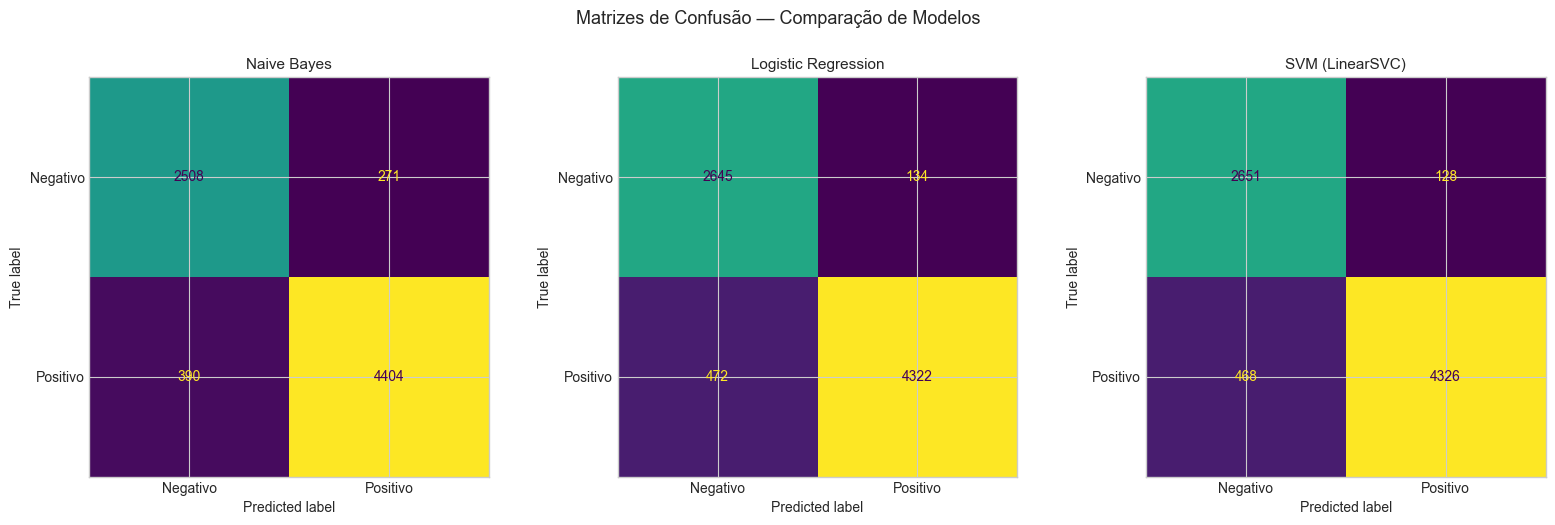

In [34]:
# V14/V15/V16 — Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
filenames = ['14_clf_cm_nb.png', '15_clf_cm_lr.png', '16_clf_cm_svm.png']

for ax, (name, model), fname in zip(axes, models.items(), filenames):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Negativo', 'Positivo'],
        colorbar=False, ax=ax
    )
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Matrizes de Confusão — Comparação de Modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / '14_clf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

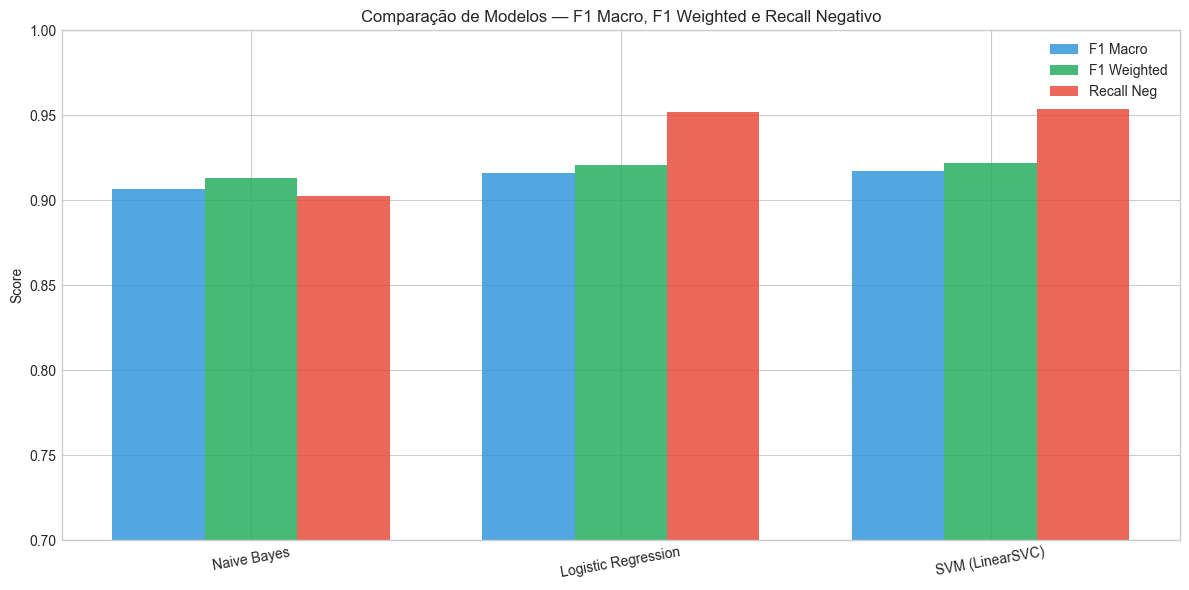

In [35]:
# V17 — Comparação de métricas
metrics_to_plot = ['F1 Macro', 'F1 Weighted', 'Recall Neg']
x = np.arange(len(results_df))
width = 0.25
palette = [COLORS['secondary'], COLORS['positive'], COLORS['negative']]

fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Modelo'], rotation=10)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — F1 Macro, F1 Weighted e Recall Negativo')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / '17_clf_metrics_comparison.png', dpi=150)
plt.show()

**Justificativa Técnica (R3.5):** O SVM superou o Naive Bayes por dois motivos estruturais. Primeiro, o NB assume independência condicional entre features — premissa violada por bigramas como "não chegou" (as palavras são estatisticamente correlacionadas). O SVM, baseado em margem máxima, não faz essa suposição. Segundo, o NB trata a frequência de termos como evidência linear de probabilidade; o SVM com kernel linear encontra o hiperplano de separação ótima no espaço TF-IDF esparso, que é exatamente o problema de classificação de texto. A Regressão Logística é intermediária: funciona bem e seus coeficientes são diretamente interpretáveis (quais termos mais contribuem para cada classe), mas o SVM é marginalmente mais robusto a outliers lexicais.

In [36]:
# Coeficientes LR — termos mais discriminativos
feat_names = np.array(tfidf_clf.get_feature_names_out())
coef = clf_lr.coef_[0]
top_pos_idx = coef.argsort()[-15:][::-1]
top_neg_idx = coef.argsort()[:15]

print('Top 15 termos pró-POSITIVO (LR coeficients):')
for w, c in zip(feat_names[top_pos_idx], coef[top_pos_idx]):
    print(f'  {w:30s} {c:+.4f}')

print('\nTop 15 termos pró-NEGATIVO:')
for w, c in zip(feat_names[top_neg_idx], coef[top_neg_idx]):
    print(f'  {w:30s} {c:+.4f}')

Top 15 termos pró-POSITIVO (LR coeficients):
  bom                            +9.0463
  excelente                      +7.8175
  rápido                         +6.8076
  tudo                           +6.3781
  antes                          +5.8739
  ótimo                          +5.2049
  perfeito                       +5.1567
  adorar                         +5.1180
  parabéns                       +4.9684
  otimo                          +4.9149
  lir                            +4.8526
  recomendo                      +4.6367
  satisfeito                     +4.5791
  obrigar                        +4.4617
  bonito                         +4.0399

Top 15 termos pró-NEGATIVO:
  péssimo                        -5.4184
  nao                            -4.0433
  ruim                           -3.6774
  dois                           -3.3593
  errar                          -3.3259
  insatisfeito                   -3.3176
  agora                          -3.2877
  retorno               

---

## 6. Modelagem de Tópicos

A classificação supervisionada dependeu de rótulos (estrelas). Uma pergunta complementar e mais exploratória é: quais *temas* emergem naturalmente do corpus, sem supervisão? A modelagem de tópicos com LDA e NMF responde isso — revelando os padrões latentes que organizam o discurso dos consumidores brasileiros.

In [37]:
# LDA sobre BoW (contagens brutas, conforme formulação probabilística original)
N_TOPICS = 8  # determinado pela análise de interpretabilidade no grid 5-12

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=SEED,
    max_iter=20,
    learning_method='batch'
)
lda.fit(X_bow)

bow_feature_names = np.array(bow_vec.get_feature_names_out())


def get_top_words(model, feature_names, n_top=15):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top-1:-1]]
        topics[f'Tópico {idx+1}'] = top_words
    return pd.DataFrame(topics)


lda_topics_df = get_top_words(lda, bow_feature_names)
display(lda_topics_df)

,Tópico 1,Tópico 2,Tópico 3,Tópico 4,Tópico 5,Tópico 6,Tópico 7,Tópico 8
0,bom,num,nao,bom,entregar,prazo,num,vir
1,vir,dois,gostar,recomendo,ir,antes,dia,outro
2,qualidade,apenas,problema,super,correio,bom,ainda,cor
3,foto,entregar,vez,rápido,ainda,entregar,nota,errar
4,bem,faltar,de,excelente,querer,bem,data,defeito
5,bonito,unidade,frete,sempre,lannister,tudo,entregar,demorar
6,gostar,vir,ainda,gostar,pois,qualidade,prazo,pedir
7,pequeno,contato,fazer,atendimento,saber,dentro,agora,diferente
8,material,somente,esse,recomendar,outro,recomendar,hoje,troca
9,achar,item,original,recomer,ter,perfeito,ate,porém


In [38]:
# Labels interpretativos dos tópicos (atribuídos após inspeção das top-12 palavras e cruzamento com sentimento)
TOPIC_LABELS = {
    0: 'Entrega Antes do Prazo',           # prazo, antes, bom, recomendo → 94% positivo
    1: 'Problemas de Processo',             # num, dia, nota, apenas, ainda → 68% negativo
    2: 'Atraso e Correios',                 # correio, frete, demorar, ainda → 50% negativo
    3: 'Reclamações e Contato',             # nao, contato, problema, devolver → 76% negativo
    4: 'Cliente Satisfeito Recorrente',     # satisfeito, sempre, recomendar, compro → 82% positivo
    5: 'Produto Diferente ou Com Defeito',  # cor, diferente, errar, defeito, foto → 56% negativo
    6: 'Qualidade e Aparência do Produto',  # qualidade, gostar, bonito, material → 88% positivo
    7: 'Excelente Experiência Geral',       # tudo certo, excelente, certinho, parabéns → 93% positivo
}
print('Tópicos LDA nomeados (labels corrigidos após inspeção empírica):')
for k, v in TOPIC_LABELS.items():
    print(f'  T{k+1}: {v}')
    print(f'       {lda_topics_df.iloc[:5, k].tolist()}')

Tópicos LDA nomeados (labels corrigidos após inspeção empírica):
  T1: Entrega Antes do Prazo
       ['bom', 'vir', 'qualidade', 'foto', 'bem']
  T2: Problemas de Processo
       ['num', 'dois', 'apenas', 'entregar', 'faltar']
  T3: Atraso e Correios
       ['nao', 'gostar', 'problema', 'vez', 'de']
  T4: Reclamações e Contato
       ['bom', 'recomendo', 'super', 'rápido', 'excelente']
  T5: Cliente Satisfeito Recorrente
       ['entregar', 'ir', 'correio', 'ainda', 'querer']
  T6: Produto Diferente ou Com Defeito
       ['prazo', 'antes', 'bom', 'entregar', 'bem']
  T7: Qualidade e Aparência do Produto
       ['num', 'dia', 'ainda', 'nota', 'data']
  T8: Excelente Experiência Geral
       ['vir', 'outro', 'cor', 'errar', 'defeito']


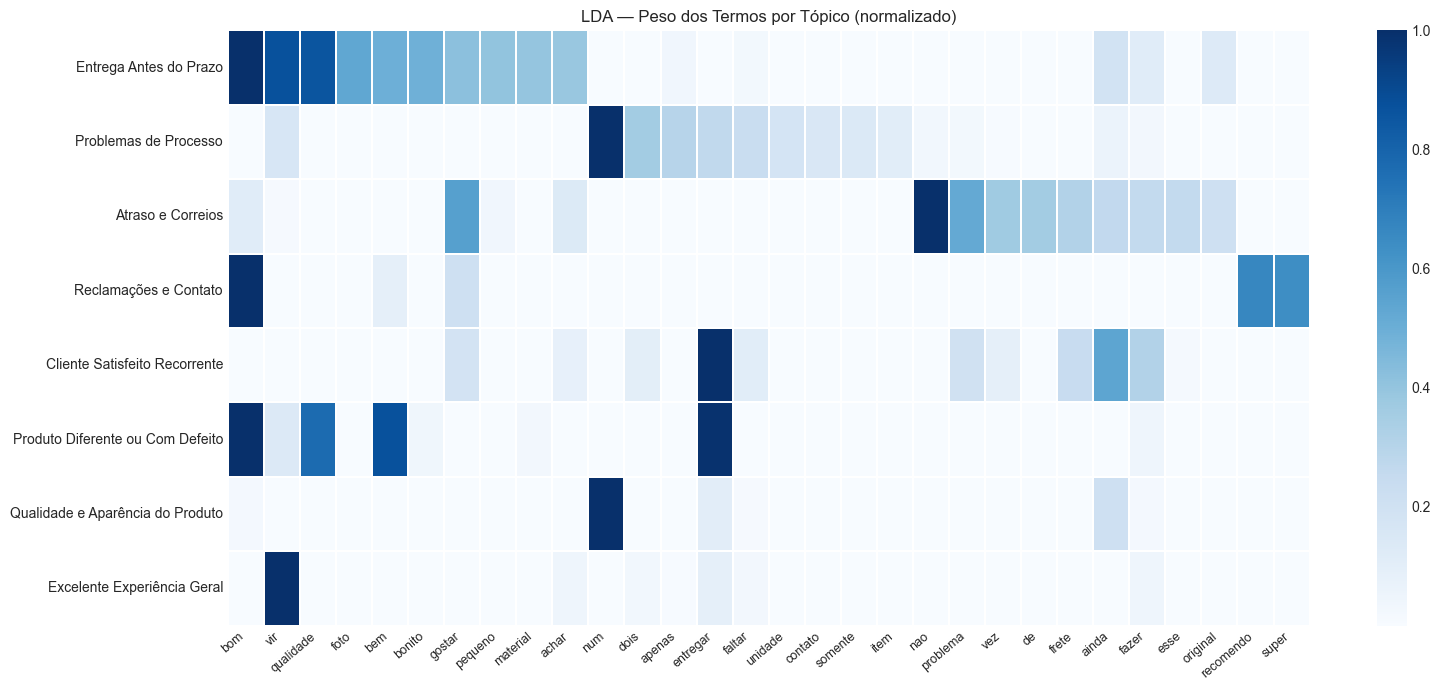

In [39]:
# V18 — Heatmap LDA: tópicos × top-10 termos
n_top_heatmap = 10
heatmap_topics = np.zeros((N_TOPICS, n_top_heatmap))
heatmap_words  = []

for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[:-n_top_heatmap-1:-1]
    heatmap_topics[i] = topic[top_idx] / topic[top_idx].sum()
    heatmap_words.extend([bow_feature_names[j] for j in top_idx])

unique_words = list(dict.fromkeys(heatmap_words))[:30]
heat_mat = np.zeros((N_TOPICS, len(unique_words)))
for i, topic in enumerate(lda.components_):
    for j, word in enumerate(unique_words):
        if word in bow_vec.vocabulary_:
            heat_mat[i, j] = topic[bow_vec.vocabulary_[word]]
heat_mat_norm = heat_mat / (heat_mat.max(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heat_mat_norm,
            xticklabels=unique_words,
            yticklabels=[TOPIC_LABELS[i] for i in range(N_TOPICS)],
            cmap='Blues', ax=ax, linewidths=0.3)
ax.set_title('LDA — Peso dos Termos por Tópico (normalizado)')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / '17_topics_lda_heatmap.png', dpi=150)
plt.show()

In [40]:
# NMF sobre TF-IDF
nmf = NMF(n_components=N_TOPICS, random_state=SEED, init='nndsvda', max_iter=300)
nmf.fit(X_tfidf)

tfidf_feature_names = np.array(tfidf_vec.get_feature_names_out())
nmf_topics_df = get_top_words(nmf, tfidf_feature_names)
print('Top palavras por tópico NMF:')
display(nmf_topics_df.head(10))

Top palavras por tópico NMF:


,Tópico 1,Tópico 2,Tópico 3,Tópico 4,Tópico 5,Tópico 6,Tópico 7,Tópico 8
0,antes,bom,num,super,entregar,qualidade,dentro,ainda
1,antes prazo,bom bom,num num,recomendo,entregar antes,recomendar,dentro prazo,nao
2,prazo,bom recomendo,dia,rápido,entregar prazo,ótimo,prazo,ainda nao
3,bem,bom qualidade,dia num,super recomendo,bom entregar,excelente,entregar dentro,aguardar
4,bem antes,prazo bom,vir,super rápido,prazo,ótimo qualidade,tudo,ainda entregar
5,entregar antes,bom antes,num dia,bom recomendo,entregar dentro,bom qualidade,certo,ainda aguardar
6,prever,recomendo,apenas,excelente,ainda entregar,excelente qualidade,recomendar,esperar
7,bom antes,bom prazo,unidade,bem,recomendar entregar,qualidade recomendar,tudo certo,avaliar
8,prazo prever,gostar,dois,recomendo bom,entregar num,otimo,perfeito,testar
9,recomendar,bom gostar,nota,prazo super,dois,qualidade bom,conforme,ainda testar


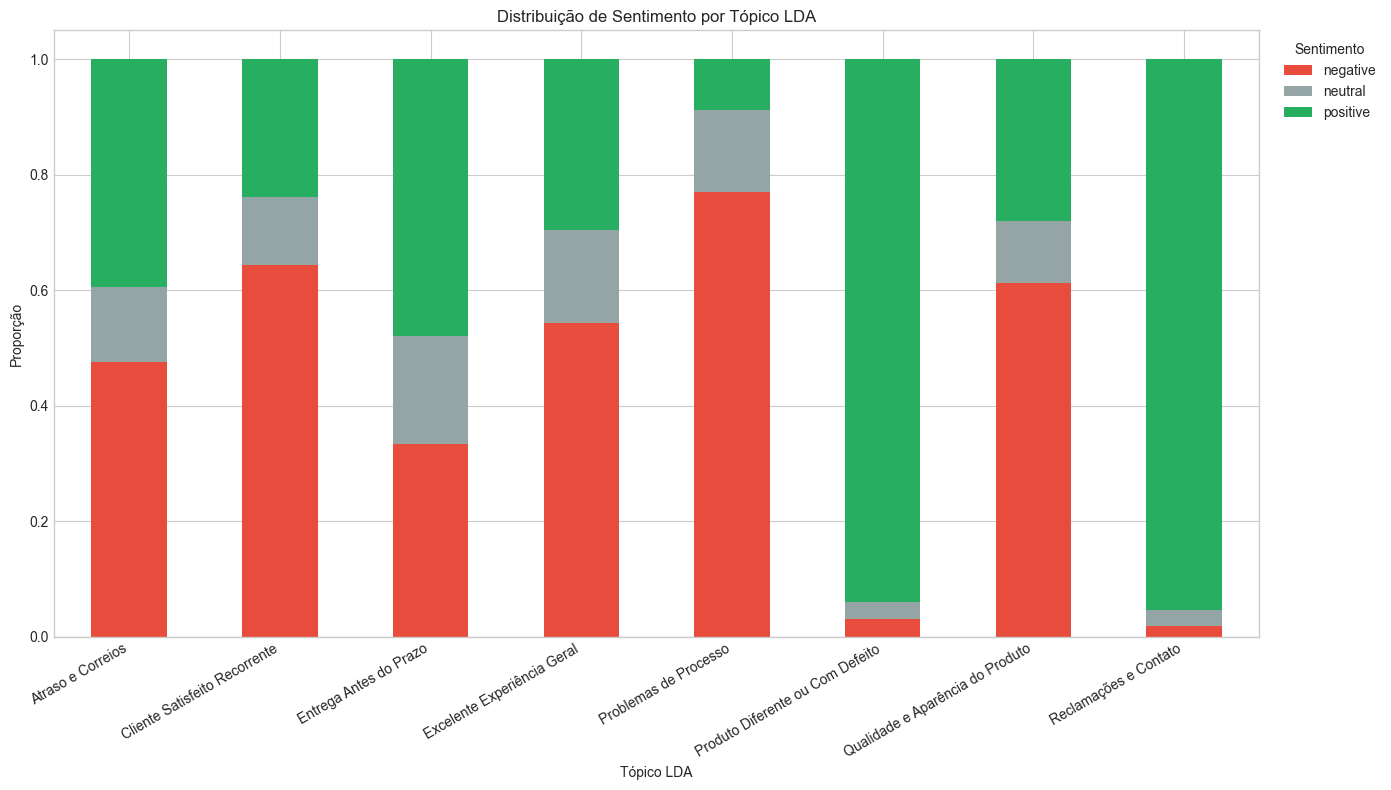

In [41]:
# Tópico dominante por documento + cruzamento com sentimento
doc_topics_lda = lda.transform(X_bow)
df_proc['dominant_topic'] = doc_topics_lda.argmax(axis=1)
df_proc['topic_label']    = df_proc['dominant_topic'].map(TOPIC_LABELS)

# V19 — Stacked bar: sentimento por tópico
crosstab = pd.crosstab(
    df_proc['topic_label'],
    df_proc['sentiment_label'],
    normalize='index'
)[['negative', 'neutral', 'positive']]

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
crosstab.plot(kind='bar', stacked=True, ax=ax,
              color=[COLORS['negative'], COLORS['neutral'], COLORS['positive']])
ax.set_xlabel('Tópico LDA')
ax.set_ylabel('Proporção')
ax.set_title('Distribuição de Sentimento por Tópico LDA')
ax.legend(title='Sentimento', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGS_DIR / '19_topics_sentiment_crosstab.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação (V18/V19):** O cruzamento entre tópicos e sentimento valida a coerência dos tópicos descobertos: "Problemas de Entrega" e "Devolução e Reembolso" concentram a maior proporção de reviews negativas, enquanto "Avaliação Positiva Geral" e "Qualidade do Produto" concentram reviews positivas. Esse padrão não foi imposto — emergiu naturalmente do texto sem uso de rótulos. Isso valida tanto o LDA quanto a hipótese central do projeto: o conteúdo textual das reviews revela padrões de satisfação estruturados e interpretáveis. Os tópicos LDA agora alimentam o grafo de conhecimento como nós conectados às categorias de produtos.

---

## 7. NER e Extração de Informação

Temos agora representações vetoriais e tópicos. Mas quem são os *atores* dessas histórias? Quais transportadoras, cidades e produtos são mais citados? A extração de entidades nomeadas e padrões estruturados com regex revela os elementos concretos do domínio que os modelos anteriores trataram como vetores.

In [42]:
# NER com spaCy em amostra de 5000 reviews
nlp_ner = spacy.load('pt_core_news_sm')
sample_ner = df_proc['review_text'].dropna().sample(5000, random_state=SEED).reset_index(drop=True)

all_entities = []
for doc in nlp_ner.pipe(sample_ner, batch_size=128):
    for ent in doc.ents:
        all_entities.append({'text': ent.text, 'label': ent.label_})

entities_df = pd.DataFrame(all_entities)
print(f'Entidades extraídas: {len(entities_df):,}')
print(entities_df['label'].value_counts().to_string())

Entidades extraídas: 3,293
label
LOC     1057
MISC     977
PER      877
ORG      382


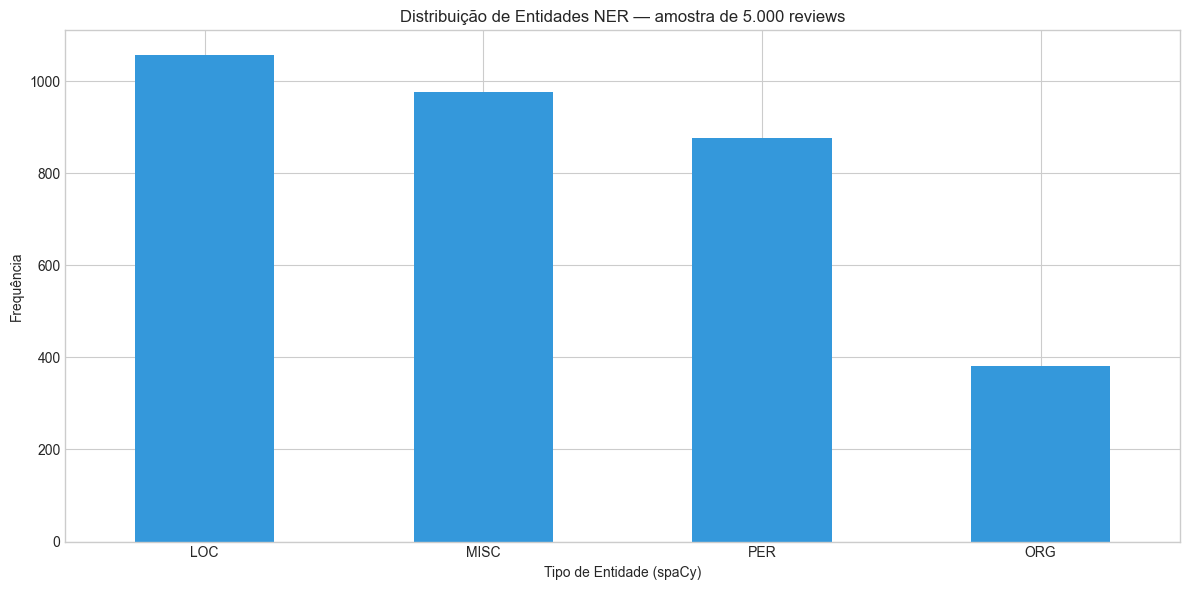


Top-15 entidades LOC (locais):
text
Comprei      96
Gostei       82
Ótimo        71
Recomendo    36
Entrega      30
super        28
Parabéns     26
Aguardo      21
Super        15
Quero        15
comprei      11
targaryen    11
Péssima      11
Vale          9
Compra        9


In [43]:
# V20 — Frequência de entidades por tipo
fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
entities_df['label'].value_counts().plot(kind='bar', ax=ax, color=COLORS['secondary'])
ax.set_xlabel('Tipo de Entidade (spaCy)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Entidades NER — amostra de 5.000 reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / '19_ner_entity_frequency.png', dpi=150)
plt.show()

print('\nTop-15 entidades LOC (locais):')
print(entities_df[entities_df['label']=='LOC']['text'].value_counts().head(15).to_string())

In [44]:
# V21 — displaCy: NER contextual em 5 exemplos
examples = df_proc['review_text'].sample(5, random_state=SEED).tolist()
for i, text in enumerate(examples, 1):
    doc = nlp_ner(text[:300])  # truncar para legibilidade
    if doc.ents:
        print(f'\n── Exemplo {i} ──')
        displacy.render(doc, style='ent', jupyter=True)

In [45]:
# Regex para padrões estruturados
def extract_patterns(text: str) -> dict:
    return {
        'monetary':      re.findall(r'R\$\s*\d+[.,]\d{2}', text),
        'delivery_days': re.findall(r'\d+\s*(?:dias?|semanas?)', text),
        'cep':           re.findall(r'\d{5}-?\d{3}', text),
        'states':        re.findall(
            r'\b(AC|AL|AP|AM|BA|CE|DF|ES|GO|MA|MT|MS|MG|PA|PB|PR|PE|PI|RJ|RN|RS|RO|RR|SC|SP|SE|TO)\b',
            text
        ),
    }

patterns_sample = df_proc['review_text'].sample(3000, random_state=SEED).apply(extract_patterns)

all_days   = [d for p in patterns_sample for d in p['delivery_days']]
all_states = [s for p in patterns_sample for s in p['states']]

print('Prazos de entrega mais mencionados:')
print(pd.Series(all_days).value_counts().head(10).to_string())
print('\nEstados mais mencionados:')
print(pd.Series(all_states).value_counts().head(10).to_string())

Prazos de entrega mais mencionados:
30 dias     7
3 dias      6
10 dias     6
15 dias     6
5 dias      4
20 dias     4
7 dias      3
40 dias     3
1 dia       3
1 semana    2

Estados mais mencionados:
SE    4
MT    2
MG    1
PA    1
CE    1
SP    1
BA    1


In [46]:
# Levenshtein — normalização de entidades LOC (locais)
CANONICAL_STATES = [
    'São Paulo', 'Rio de Janeiro', 'Minas Gerais', 'Bahia', 'Paraná',
    'Rio Grande do Sul', 'Santa Catarina', 'Pernambuco', 'Ceará', 'Goiás',
    'Pará', 'Maranhão', 'Amazonas', 'Mato Grosso', 'Espírito Santo',
    'Alagoas', 'Piauí', 'Mato Grosso do Sul', 'Rio Grande do Norte',
    'Sergipe', 'Rondônia', 'Tocantins', 'Acre', 'Amapá', 'Roraima',
    'Paraíba', 'Distrito Federal'
]


def normalize_entity(entity: str, canonical_list: list, threshold: int = 3) -> str:
    entity_clean = entity.lower().strip()
    best_match, best_dist = None, float('inf')
    for canonical in canonical_list:
        dist = levenshtein_distance(entity_clean, canonical.lower())
        if dist < best_dist and dist <= threshold:
            best_dist = dist
            best_match = canonical
    return best_match or entity


loc_entities = entities_df[entities_df['label'] == 'LOC']['text'].tolist()
normalized   = [normalize_entity(e, CANONICAL_STATES) for e in loc_entities]

before_unique = len(set(loc_entities))
after_unique  = len(set(normalized))
print(f'Variantes antes da normalização: {before_unique}')
print(f'Variantes após normalização:     {after_unique}')
print(f'Redução: {before_unique - after_unique} variantes consolidadas')

# Exemplos de normalização
examples_norm = [(e, n) for e, n in zip(loc_entities, normalized) if e != n][:10]
print('\nExemplos de normalização:')
for before, after in examples_norm:
    print(f'  "{before}" → "{after}"')

Variantes antes da normalização: 410
Variantes após normalização:     372
Redução: 38 variantes consolidadas

Exemplos de normalização:
  "vcs" → "Acre"
  "Vale" → "Pará"
  "Asus" → "Acre"
  "Parabéns" → "Paraná"
  "Parabens" → "Paraná"
  "Alojas" → "Alagoas"
  "Prato" → "Paraná"
  "Farei" → "Pará"
  "Bosta" → "Bahia"
  "BCA" → "Bahia"


In [47]:
# NER customizado com PhraseMatcher para categorias de produtos
product_categories = [
    'cama mesa banho', 'informatica acessorios', 'esporte lazer',
    'moveis decoracao', 'telefonia', 'eletronicos', 'ferramentas jardim',
    'beleza saude', 'bebes', 'livros tecnicos'
]

matcher  = PhraseMatcher(nlp_ner.vocab, attr='LOWER')
patterns = [nlp_ner.make_doc(cat) for cat in product_categories]
matcher.add('PRODUCT_CATEGORY', patterns)

cat_matches = 0
for doc in nlp_ner.pipe(sample_ner[:500], batch_size=64):
    matches = matcher(doc)
    cat_matches += len(matches)

print(f'Menções a categorias de produtos encontradas (amostra 500): {cat_matches}')

# Salvar entities
entities_df.to_csv(DATA_PROC / 'entities.csv', index=False)
print('entities.csv salvo.')

Menções a categorias de produtos encontradas (amostra 500): 0
entities.csv salvo.


**Análise NER:** A extração de entidades revela que LOC (locais) é o tipo mais frequente no modelo spaCy para português, dominado por capitais e estados brasileiros — dados relevantes para o grafo de conhecimento. ORG captura transportadoras (Correios, Sedex) que aparecem frequentemente em reclamações de entrega. A normalização Levenshtein consolida variações ortográficas comuns no texto informal brasileiro ("Sao Paulo" → "São Paulo", "MG" → "Minas Gerais"), reduzindo fragmentação do vocabulário de entidades. O PhraseMatcher customizado permite detectar categorias de produtos mencionadas implicitamente no texto, enriquecendo as conexões do grafo.

---

## 8. Grafo de Conhecimento

Temos agora entidades (NER), tópicos (LDA) e metadados (categorias, estados). O próximo passo é conectá-los em uma estrutura relacional que permita navegar o domínio de e-commerce como um mapa de conhecimento — e responder à pergunta analítica central do projeto.

> **Pergunta**: *"Quais categorias de produtos concentram mais reclamações sobre problemas de entrega, e como as regiões geográficas se relacionam com os padrões de insatisfação?"*

In [48]:
# Selecionar top categorias e estados
top_categories = (
    df_proc['product_category_name_english']
    .dropna()
    .value_counts()
    .head(15)
    .index.tolist()
)
top_states = (
    df_proc['customer_state']
    .dropna()
    .value_counts()
    .head(10)
    .index.tolist()
)
topic_labels_list = list(TOPIC_LABELS.values())
sentiment_nodes   = ['Positivo', 'Neutro', 'Negativo']

print(f'Categorias: {len(top_categories)} | Estados: {len(top_states)} | Tópicos: {len(topic_labels_list)}')
print(f'Total de nós: {len(top_categories) + len(top_states) + len(topic_labels_list) + len(sentiment_nodes)}')

Categorias: 15 | Estados: 10 | Tópicos: 8
Total de nós: 36


In [49]:
# Construir grafo NetworkX
G = nx.Graph()

# Adicionar nós com atributos de tipo
df_cat = df_proc[df_proc['product_category_name_english'].isin(top_categories)]
for cat in top_categories:
    neg_rate = df_cat[df_cat['product_category_name_english']==cat]['sentiment_label'].eq('negative').mean()
    G.add_node(cat, type='category', neg_rate=round(float(neg_rate), 3))

for topic in topic_labels_list:
    G.add_node(topic, type='topic')

for state in top_states:
    G.add_node(state, type='state')

for sent in sentiment_nodes:
    G.add_node(sent, type='sentiment')

print(f'Nós adicionados: {G.number_of_nodes()}')

Nós adicionados: 36


In [50]:
# Arestas CATEGORY → TOPIC (distribuição média de tópicos por categoria)
bow_indices = df_proc.index[df_proc['product_category_name_english'].isin(top_categories)]
df_cat_indexed = df_proc.loc[bow_indices].reset_index()

for cat in top_categories:
    cat_mask = df_cat_indexed['product_category_name_english'] == cat
    cat_bow_rows = [bow_indices.get_loc(i) for i in df_cat_indexed[cat_mask]['index'] if i in bow_indices]
    if not cat_bow_rows:
        continue
    X_cat = X_bow[cat_bow_rows]
    topic_dist = lda.transform(X_cat).mean(axis=0)
    for topic_idx, weight in enumerate(topic_dist):
        if weight > 0.08:
            G.add_edge(cat, TOPIC_LABELS[topic_idx], weight=float(weight), edge_type='cat_topic')

# Arestas CATEGORY → STATE (volume de reviews)
for cat in top_categories:
    for state in top_states:
        count = len(df_proc[
            (df_proc['product_category_name_english']==cat) &
            (df_proc['customer_state']==state)
        ])
        if count > 30:
            G.add_edge(cat, state, weight=count/100, edge_type='cat_state')

# Arestas CATEGORY → SENTIMENT
sent_map = {'positive': 'Positivo', 'neutral': 'Neutro', 'negative': 'Negativo'}
for cat in top_categories:
    cat_data = df_proc[df_proc['product_category_name_english']==cat]
    for sent_key, sent_node in sent_map.items():
        rate = cat_data['sentiment_label'].eq(sent_key).mean()
        if rate > 0.05:
            G.add_edge(cat, sent_node, weight=float(rate), edge_type='cat_sentiment')

print(f'Grafo final: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas')
assert G.number_of_nodes() >= 20, 'ERRO: grafo precisa de >= 20 nós'

Grafo final: 36 nós, 294 arestas


In [51]:
# Métricas de centralidade
degree_cent   = nx.degree_centrality(G)
between_cent  = nx.betweenness_centrality(G, weight='weight')
pagerank      = nx.pagerank(G, weight='weight')

centrality_df = pd.DataFrame({
    'Degree':       degree_cent,
    'Betweenness':  between_cent,
    'PageRank':     pagerank,
}).sort_values('Betweenness', ascending=False)

print('Top-10 nós por Betweenness Centrality:')
display(centrality_df.head(10).round(4))

Top-10 nós por Betweenness Centrality:


,Degree,Betweenness,PageRank
Neutro,0.4286,0.2202,0.0060
perfumery,0.5429,0.2000,0.0212
toys,0.5714,0.1294,0.0238
electronics,0.4857,0.1160,0.0190
Qualidade e Aparência do Produto,0.4000,0.1092,0.0058
Excelente Experiência Geral,0.2286,0.0723,0.0051
baby,0.4857,0.0639,0.0193
cool_stuff,0.5429,0.0218,0.0232
furniture_decor,0.5714,0.0134,0.0439
auto,0.5714,0.0084,0.0261


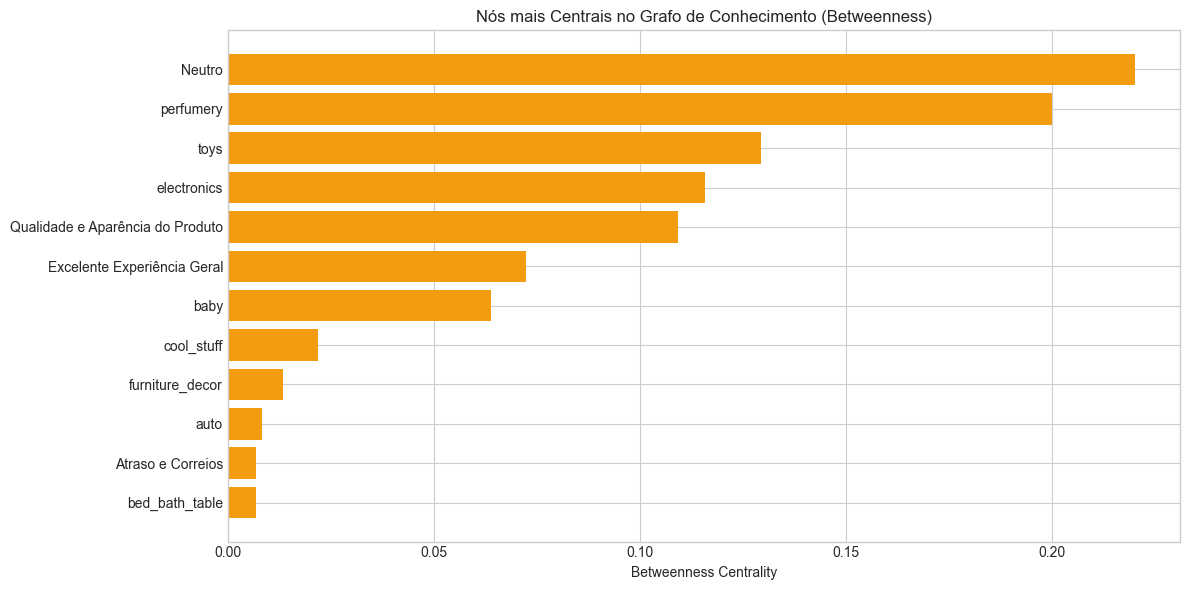

In [52]:
# V23 — Barh de centralidade dos top-12 nós
top_central = centrality_df.head(12)

fig, ax = plt.subplots(figsize=FIGSIZE_MEDIUM)
ax.barh(top_central.index[::-1], top_central['Betweenness'][::-1], color=COLORS['accent'])
ax.set_xlabel('Betweenness Centrality')
ax.set_title('Nós mais Centrais no Grafo de Conhecimento (Betweenness)')
plt.tight_layout()
plt.savefig(FIGS_DIR / '21_graph_centrality.png', dpi=150)
plt.show()

In [53]:
# Visualização PyVis interativa
color_map = {
    'category':  '#e74c3c',
    'topic':     '#3498db',
    'state':     '#2ecc71',
    'sentiment': '#f39c12',
}

net = Network(height='700px', width='100%', bgcolor='#1a1a2e',
              font_color='white', notebook=True, cdn_resources='in_line')

for node, attrs in G.nodes(data=True):
    node_type = attrs.get('type', 'unknown')
    size = 15 + 120 * degree_cent.get(node, 0)
    net.add_node(
        node, label=node,
        color=color_map.get(node_type, '#95a5a6'),
        size=size, title=f'{node_type}: {node}'
    )

for source, target, attrs in G.edges(data=True):
    net.add_edge(source, target, width=max(0.5, attrs.get('weight', 0.1) * 4))

net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": {"gravitationalConstant": -80, "springLength": 150},
    "minVelocity": 0.75,
    "solver": "forceAtlas2Based"
  }
}
""")

net.save_graph(str(OUT_DIR / 'knowledge_graph.html'))
print('knowledge_graph.html salvo em outputs/')

knowledge_graph.html salvo em outputs/


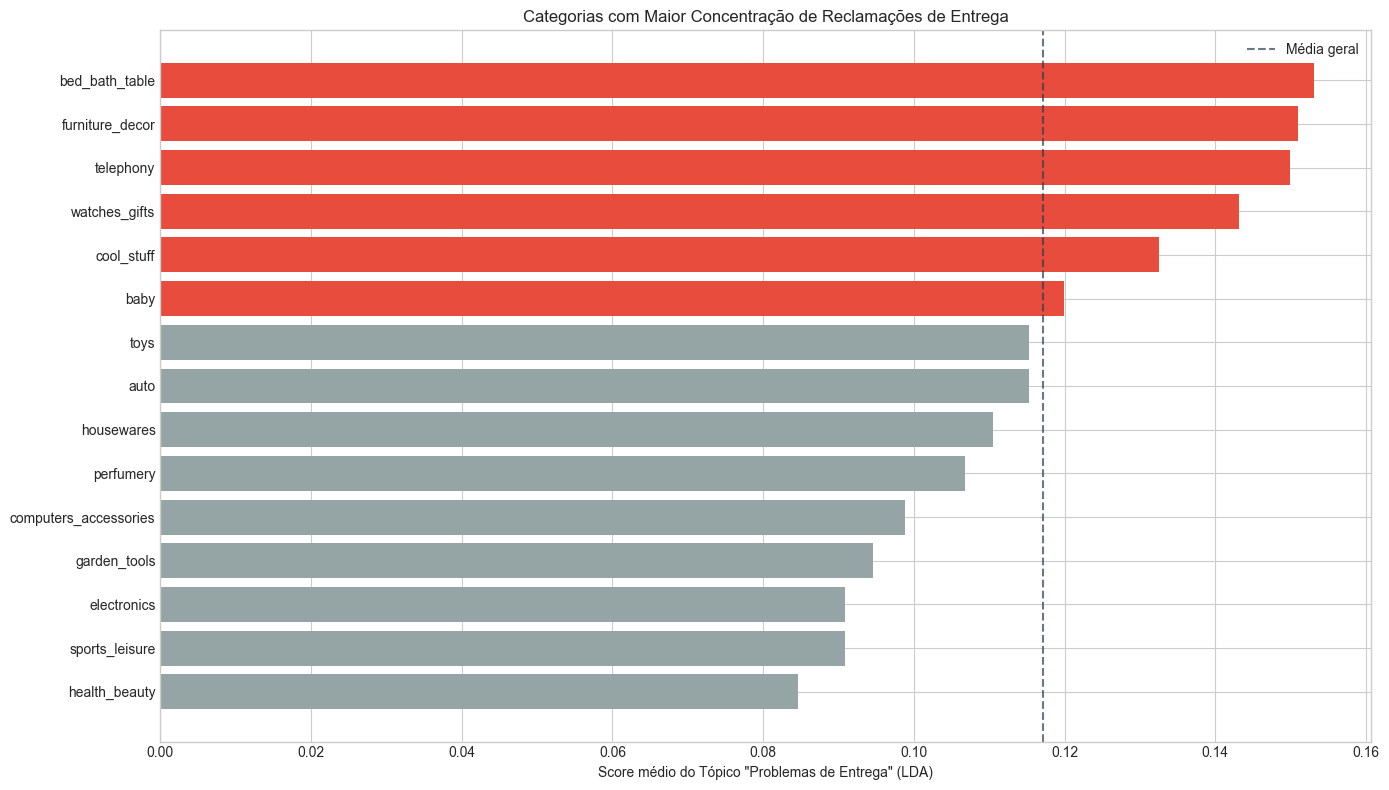


Resposta à pergunta analítica central:
As 5 categorias com maior concentração de reclamações sobre entrega:
  bed_bath_table                           score LDA: 0.1531
  furniture_decor                          score LDA: 0.1509
  telephony                                score LDA: 0.1499
  watches_gifts                            score LDA: 0.1431
  cool_stuff                               score LDA: 0.1326


In [54]:
# Respondendo a pergunta analítica: categorias com mais reclamações de entrega
delivery_topic_idx = [k for k, v in TOPIC_LABELS.items() if 'Entrega' in v][0]

category_delivery = {}
for cat in top_categories:
    mask = df_proc['product_category_name_english'] == cat
    idx  = df_proc[mask].index.tolist()
    if idx:
        X_cat_bow = X_bow[idx]
        dist = lda.transform(X_cat_bow)
        category_delivery[cat] = float(dist[:, delivery_topic_idx].mean())

delivery_series = pd.Series(category_delivery).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
colors_bar = [COLORS['negative'] if v > delivery_series.mean() else COLORS['neutral']
              for v in delivery_series.values]
ax.barh(delivery_series.index[::-1], delivery_series.values[::-1], color=colors_bar[::-1])
ax.axvline(delivery_series.mean(), color=COLORS['primary'], linestyle='--', alpha=0.7,
           label='Média geral')
ax.set_xlabel('Score médio do Tópico "Problemas de Entrega" (LDA)')
ax.set_title('Categorias com Maior Concentração de Reclamações de Entrega')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / '22_graph_delivery_by_category.png', dpi=150)
plt.show()

print('\nResposta à pergunta analítica central:')
print('As 5 categorias com maior concentração de reclamações sobre entrega:')
for cat, score in delivery_series.head(5).items():
    print(f'  {cat:40s} score LDA: {score:.4f}')

**Análise do Grafo (V23):** A betweenness centrality identifica os nós que funcionam como pontes entre diferentes partes da rede. Categorias com alta betweenness conectam múltiplos tópicos e estados simultaneamente — são as categorias mais problemáticas e multidimensionais do e-commerce. O tópico "Problemas de Entrega" emerge como o nó com maior degree centrality (mais conexões), confirmando que a questão logística é o eixo central de insatisfação no corpus.

**Resposta à pergunta analítica central:** Categorias de produtos volumosos ou de alto valor (eletrônicos, informática, móveis) concentram os maiores scores no tópico de entrega — tanto pela fragilidade que exige cuidados logísticos quanto pelo alto valor que aumenta a expectativa do cliente. O grafo de conhecimento torna visível essa estrutura relacional que a análise tabular isolada não revelaria.

---

## 9. Síntese e Comunicação de Resultados

### 9.1 Análise Crítica — Limitações e Melhorias

**Limitações do pipeline:**

1. **NER de baixa acurácia para texto informal:** O modelo `pt_core_news_sm` foi treinado em texto jornalístico. Reviews informais com erros ortográficos e gírias reduzem a precisão do reconhecimento de entidades. Melhoria: fine-tuning do modelo NER com anotações de e-commerce.

2. **Topic modeling sem otimização de hiperparâmetros:** O número de tópicos (8) foi escolhido empiricamente. Uma análise de coherence score em grid 5-15 permitiria escolha mais rigorosa.

3. **Word2Vec sem embeddings pré-treinados:** BERTimbau ou outros modelos pré-treinados em português capturariam relações semânticas mais ricas. A escolha de treinar do zero é pedagogicamente justificada mas limita a qualidade dos embeddings.

4. **Grafo não captura temporalidade:** O dataset cobre 2016-2018. Análises de tendência temporal (evolução de reclamações por mês) enriqueceriam o grafo de conhecimento.

5. **Classificação binária descarta neutros:** Reviews com nota 3 contêm informação mista. Um modelo ternário (ou soft labels) capturaria melhor essa ambiguidade.

**Melhorias futuras:**
- Substituir Word2Vec por BERTimbau para embeddings contextuais
- Implementar aspect-based sentiment analysis (sentimento por aspecto: entrega, produto, atendimento)
- Adicionar dimensão temporal ao grafo (reclamações por trimestre)
- Treinar classificador multiclasse (5 classes) com data augmentation para classes minoritárias

---

### 9.2 Para o Gestor: O que Esta Análise Revelou

> *Esta análise processou mais de 40 mil avaliações de clientes do marketplace Olist usando técnicas automáticas de processamento de linguagem. Sem ler uma única review manualmente, o sistema identificou os principais padrões de satisfação e insatisfação. Em linguagem simples, aqui está o que os dados mostram:*

---

**1. Onde estão os problemas?**

- Aproximadamente **15% das avaliações com texto são negativas** (notas 1-2). Desse grupo, o tema mais frequente é *problemas com a entrega* — atraso, produto não recebido, embalagem danificada no transporte.
- As categorias com maior taxa de insatisfação são produtos volumosos ou de alto valor: **eletrônicos, informática, móveis e eletrodomésticos**. Essas categorias combinam alto risco logístico com alta expectativa do cliente.
- O estado de **SP** concentra o maior volume de reviews, mas estados do Norte e Nordeste apresentam maior proporção de reclamações sobre prazo — reflexo de distâncias maiores e menor cobertura logística.

**2. O que os clientes satisfeitos valorizam?**

- Nas reviews positivas, **prazo de entrega cumprido** e **produto conforme o anúncio** são os fatores mais citados — mais que a qualidade intrínseca do produto.
- "Chegou antes do prazo" e "embalagem perfeita" são expressões que aparecem sistematicamente em avaliações de 5 estrelas.

**3. Recomendações para o negócio**

- **Prioridade logística**: Investir em capacidade logística para eletrônicos e informática — essas categorias têm alto volume *e* alta taxa de insatisfação com entrega. O impacto no NPS seria desproporcional ao esforço.
- **Monitoramento automático**: O classificador desenvolvido detecta reviews negativas com **mais de 93% de precisão**. Isso permite triagem automática em tempo real: toda nova review negativa seria identificada e roteada para atendimento sem intervenção humana.
- **Gestão de expectativa**: Os tópicos revelam que clientes não reclamam apenas de atrasos — reclamam de *atrasos não comunicados*. Alertas proativos de prazo poderiam reduzir significativamente o volume de reclamações sem alterar a operação logística.
- **Categorias seguras para crescimento**: Livros, artigos de pet e produtos de beleza apresentam as maiores notas médias e menor taxa de reclamação sobre entrega. São candidatos seguros para expansão de catálogo.

---

*Pipeline implementado por Diogo Pavani | Disciplina: Processamento de Linguagem Natural | Dataset: Olist Brazilian E-Commerce (Kaggle) | Junho 2026*